# Data Engineering Challenges 

**City:** New York City, USA  
**Data Source:** Inside Airbnb — scrape date 2026-06-23  
**Purpose:** Clean the raw data files so every downstream notebook (EDA, statistics) starts with trustworthy data.

3.1  Data Inges on & Profiling 

### 3.1.1 Repeatable Ingestion Pipeline

1. Defines the Inside Airbnb URL for New York City  
2. Creates the `data/raw/` folder if it does not exist  
3. Downloads each file only if it is not already on disk (so re-running is fast)  
4. Loads all four files into pandas DataFrames  
5. Prints a confirmation that loading succeeded

In [ ]:
import os
import urllib.request
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", "{:.2f}".format)

# ── 1. Define source URLs (Inside Airbnb — New York City, June 2026) ──
BASE_URL = "https://data.insideairbnb.com/united-states/ny/new-york-city/2026-06-23/data/"

FILES = {
    "listings.csv.gz":      BASE_URL + "listings.csv.gz",
    "calendar.csv.gz":      BASE_URL + "calendar.csv.gz",
    "reviews.csv":       BASE_URL + "reviews.csv",
    "neighbourhoods.csv":   BASE_URL.replace("data/", "visualisations/") + "neighbourhoods.csv",
}

RAW_DIR = "data/raw"
os.makedirs(RAW_DIR, exist_ok=True)

# ── 2. Download each file only if not already on disk ─────────────────
print("Ingestion pipeline — checking / downloading files")
print("=" * 55)
for filename, url in FILES.items():
    dest = os.path.join(RAW_DIR, filename)
    if os.path.exists(dest):
        size_mb = os.path.getsize(dest) / 1_048_576
        print(f"  SKIP  {filename:<30} already on disk ({size_mb:.1f} MB)")
    else:
        print(f"  DOWN  {filename:<30} downloading ...", end=" ")
        urllib.request.urlretrieve(url, dest)
        size_mb = os.path.getsize(dest) / 1_048_576
        print(f"done ({size_mb:.1f} MB)")

print()
print("All files ready.")


Ingestion pipeline — checking / downloading files
  SKIP  listings.csv.gz                already on disk (15.0 MB)
  SKIP  calendar.csv.gz                already on disk (24.7 MB)
  SKIP  reviews.csv.gz                 already on disk (113.9 MB)
  SKIP  neighbourhoods.csv             already on disk (0.0 MB)

All files ready.


In [ ]:
# ── 3. Load all four files into DataFrames ────────────────────────────
listings       = pd.read_csv(os.path.join(RAW_DIR, "listings.csv.gz"))
calendar       = pd.read_csv(os.path.join(RAW_DIR, "calendar.csv.gz"))
reviews        = pd.read_csv(os.path.join(RAW_DIR, "reviews.csv"))
neighbourhoods = pd.read_csv(os.path.join(RAW_DIR, "neighbourhoods.csv"))

# ── 4. Confirm shapes ────────────────────────────────────────────────
print("Load confirmation")
print("=" * 50)
for name, df in [("listings", listings), ("calendar", calendar),
                 ("reviews", reviews), ("neighbourhoods", neighbourhoods)]:
    print(f"  {name:<18} {df.shape[0]:>8,} rows  ×  {df.shape[1]:>3} columns")


Load confirmation
  listings             30,259 rows  ×   90 columns
  calendar           11,152,576 rows  ×    5 columns
  reviews             990,170 rows  ×    6 columns
  neighbourhoods          230 rows  ×    2 columns


---
### 3.1.2 Profile Each Dataset

- **Row counts** — how big is each file?
- **Column cardinality** — how many unique values does each column have? 
- **Null rates** — what percentage of values are missing per column?
- **Data type distributions** — how many columns are numeric vs. text vs. boolean?


In [137]:
def profile_dataframe(name, df):
    """Print a full profile report for one DataFrame."""
    print(f"\n{'='*65}")
    print(f"  PROFILE: {name}   ({df.shape[0]:,} rows × {df.shape[1]} columns)")
    print(f"{'='*65}")

    # dtype distribution summary
    dtype_counts = df.dtypes.value_counts()
    print("\nDtype distribution:")
    for dtype, count in dtype_counts.items():
        print(f"  {str(dtype):<15} {count:>3} column(s)")

    # per-column profile
    print(f"\n{'Column':<45} {'Dtype':<12} {'Nulls':>7} {'Null%':>7} {'Unique':>8}")
    print("-" * 82)
    for col in df.columns:
        dtype    = str(df[col].dtype)
        n_null   = df[col].isnull().sum()
        pct_null = n_null / len(df) * 100
        n_unique = df[col].nunique(dropna=True)
        print(f"  {col:<43} {dtype:<12} {n_null:>7,} {pct_null:>6.1f}% {n_unique:>8,}")

for name, df in [("listings", listings), ("calendar", calendar),
                 ("reviews", reviews), ("neighbourhoods", neighbourhoods)]:
    profile_dataframe(name, df)



  PROFILE: listings   (30,259 rows × 90 columns)

Dtype distribution:
  float64          42 column(s)
  str              30 column(s)
  int64            18 column(s)

Column                                        Dtype          Nulls   Null%   Unique
----------------------------------------------------------------------------------
  id                                          int64              0    0.0%   30,259
  listing_url                                 str                0    0.0%   30,259
  scrape_id                                   int64              0    0.0%        1
  last_scraped                                str                0    0.0%        4
  source                                      str                0    0.0%        2
  name                                        str                1    0.0%   28,835
  description                                 str              902    3.0%   24,173
  neighborhood_overview                       float64       30,259  100.0%   

In [206]:
listings.info()

<class 'pandas.DataFrame'>
RangeIndex: 30259 entries, 0 to 30258
Data columns (total 90 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            30259 non-null  int64  
 1   listing_url                                   30259 non-null  str    
 2   scrape_id                                     30259 non-null  int64  
 3   last_scraped                                  30259 non-null  str    
 4   source                                        30259 non-null  str    
 5   name                                          30258 non-null  str    
 6   description                                   29357 non-null  str    
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   30259 non-null  str    
 9   host_id                                       30259 non-null  int64  
 1

In [207]:
# ── Numeric columns — descriptive statistics (listings) ───────────────
print("listings — numeric column statistics")
print("=" * 65)
print(listings.select_dtypes(include="number").describe().T.to_string())


listings — numeric column statistics
                                                count                   mean                   std                    min                    25%                    50%                    75%                    max
id                                           30259.00  617251296458194944.00 615514695928849024.00                2539.00            30387600.50  660878177372429184.00 1160901301442758912.00 1707074575928715520.00
scrape_id                                    30259.00      20260614073253.00                  0.00      20260614073253.00      20260614073253.00      20260614073253.00      20260614073253.00      20260614073253.00
neighborhood_overview                            0.00                    NaN                   NaN                    NaN                    NaN                    NaN                    NaN                    NaN
host_id                                      30259.00    2672814739649950.50  67057431226841872.00         

In [208]:
# ── Categorical cardinality spotlight (listings) ──────────────────────
# Columns with 2–50 unique values are the most useful for grouping
cat_cols = listings.select_dtypes(include=["object", "str"]).columns
cardinality = listings[cat_cols].nunique().sort_values()
low_card = cardinality[cardinality <= 50]

print("Categorical columns with ≤ 50 unique values (useful for grouping)")
print("=" * 60)
for col, n in low_card.items():
    top_vals = listings[col].value_counts(dropna=False).head(5).to_dict()
    print(f"\n  {col}  ({n} unique)")
    for val, cnt in top_vals.items():
        print(f"    {str(val):<35} {cnt:>6,}")


Categorical columns with ≤ 50 unique values (useful for grouping)

  source  (2 unique)
    city scrape                         21,461
    previous scrape                      8,798

  host_identity_verified  (2 unique)
    t                                   28,555
    f                                    1,355
    nan                                    349

  host_has_profile_pic  (2 unique)
    t                                   28,876
    f                                    1,034
    nan                                    349

  host_is_superhost  (2 unique)
    f                                   22,814
    t                                    7,096
    nan                                    349

  has_availability  (2 unique)
    t                                   29,563
    f                                      349
    nan                                    347

  last_scraped  (4 unique)
    2026-06-14                          14,356
    2026-06-15                          

In [209]:
cat_cols = listings.select_dtypes(include=["object", "str"]).columns
cardinality = listings[cat_cols].nunique().sort_values(ascending=False)
high_card = cardinality[cardinality > 1000]

print("High-cardinality columns (> 1000 unique values) — likely IDs or free text")
print("=" * 60)
print(high_card.to_string())
print("Constant columns (only 1 unique value — useless for analysis)")
print("=" * 55)
for col in listings.columns:
    if listings[col].nunique(dropna=True) <= 1:
        val = listings[col].dropna().unique()
        print(f"  {col:<45} only value: {val}")

High-cardinality columns (> 1000 unique values) — likely IDs or free text
listing_url         30259
picture_url         29608
name                28835
amenities           25118
description         24173
price_quote_raw     19766
host_url            16474
host_profile_url    16386
host_picture_url    15949
price               11417
host_about           9242
host_name            7001
first_review         4595
last_review          3268
license              2019
Constant columns (only 1 unique value — useless for analysis)
  scrape_id                                     only value: [20260614073253]
  neighborhood_overview                         only value: []
  host_since                                    only value: []
  host_response_time                            only value: []
  host_response_rate                            only value: []
  host_acceptance_rate                          only value: []
  host_thumbnail_url                            only value: []
  host_neighbourhoo

**Quality dimensions we measure:**

| Dimension | Definition |
|-----------|------------|
| **Completeness** | What % of expected values are present (non-null)? |
| **Validity** | Do values conform to expected format/range? |
| **Uniqueness** | Are there duplicate rows? |
| **Consistency** | Are the same concepts stored the same way? |

In [210]:
def quality_report(name, df):
    """Print a structured quality report for one DataFrame."""
    total_cells  = df.shape[0] * df.shape[1]
    null_cells   = df.isnull().sum().sum()
    completeness = 100 - (null_cells / total_cells * 100)
    dup_rows     = df.duplicated().sum()

    # ── Quality score (weighted: completeness 70%, uniqueness 30%) ────
    uniqueness_score = 100 - (dup_rows / len(df) * 100)
    quality_score    = (completeness * 0.7) + (uniqueness_score * 0.3)
    grade = "A" if quality_score >= 90 else "B" if quality_score >= 75 else "C" if quality_score >= 60 else "D"

    print(f"\n{'━'*60}")
    print(f"  DATA QUALITY REPORT — {name}")
    print(f"  Quality Score : {quality_score:.1f}/100  (Grade: {grade})")
    print(f"{'━'*60}")
    print(f"  Rows               : {df.shape[0]:>10,}")
    print(f"  Columns            : {df.shape[1]:>10,}")
    print(f"  Total cells        : {total_cells:>10,}")
    print(f"  Null cells         : {null_cells:>10,}")
    print(f"  Overall completeness: {completeness:>9.1f}%")
    print(f"  Duplicate rows     : {dup_rows:>10,}")

    # ── Columns that are 100% null — scraping failures ────────────────
    dead_cols = [c for c in df.columns if df[c].isnull().all()]
    print(f"\n  Columns 100% null (unusable): {len(dead_cols)}")
    for c in dead_cols:
        print(f"    • {c}")

    # ── Columns with 20–99% null — use with caution ───────────────────
    partial_cols = [(c, df[c].isnull().mean()*100)
                    for c in df.columns
                    if 20 <= df[c].isnull().mean()*100 < 100]
    partial_cols.sort(key=lambda x: -x[1])
    print(f"\n  Columns 20–99% null (use with caution): {len(partial_cols)}")
    for c, pct in partial_cols:
        severity = "CRITICAL" if pct >= 80 else "HIGH" if pct >= 50 else "MODERATE"
        print(f"    • {c:<45} {pct:.1f}%  [{severity}]")

    # ── Columns with wrong dtype (object but should be number/date) ───
    suspicious = []
    for c in df.select_dtypes(include=["object", "str"]).columns:
        sample = df[c].dropna().head(100)
        numeric_like = pd.to_numeric(sample.str.replace(r"[\$,%,]", "", regex=True), errors="coerce").notna().mean()
        date_like    = pd.to_datetime(sample, format="mixed", errors="coerce").notna().mean()
        if numeric_like > 0.8:
            suspicious.append((c, "stored as text — likely numeric"))
        elif date_like > 0.8:
            suspicious.append((c, "stored as text — likely date"))

    print(f"\n  Columns with wrong dtype (need fixing): {len(suspicious)}")
    for c, reason in suspicious:
        print(f"    • {c:<45} {reason}")

for name, df in [("listings", listings), ("calendar", calendar),
                 ("reviews", reviews), ("neighbourhoods", neighbourhoods)]:
    quality_report(name, df)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  DATA QUALITY REPORT — listings
  Quality Score : 84.9/100  (Grade: B)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Rows               :     30,259
  Columns            :         90
  Total cells        :  2,723,310
  Null cells         :    587,113
  Overall completeness:      78.4%
  Duplicate rows     :          0

  Columns 100% null (unusable): 12
    • neighborhood_overview
    • host_since
    • host_response_time
    • host_response_rate
    • host_acceptance_rate
    • host_thumbnail_url
    • host_neighbourhood
    • host_total_listings_count
    • host_verifications
    • neighbourhood
    • calendar_updated
    • instant_bookable

  Columns 20–99% null (use with caution): 23
    • license                                       82.5%  [CRITICAL]
    • host_about                                    41.0%  [MODERATE]
    • bedrooms                                      36.3%  [MODERATE]
    • bathroo

In [211]:
# ── Overall quality score across all files ────────────────────────────
print("\nOverall quality score by file")
print("=" * 45)
for name, df in [("listings", listings), ("calendar", calendar),
                 ("reviews", reviews), ("neighbourhoods", neighbourhoods)]:
    total  = df.shape[0] * df.shape[1]
    nulls  = df.isnull().sum().sum()
    score  = 100 - (nulls / total * 100)
    dups   = df.duplicated().sum()
    print(f"  {name:<18} completeness={score:5.1f}%   duplicates={dups:,}")



Overall quality score by file
  listings           completeness= 78.4%   duplicates=0
  calendar           completeness=100.0%   duplicates=0
  reviews            completeness=100.0%   duplicates=0
  neighbourhoods     completeness=100.0%   duplicates=0


### 3.1.4 Duplicate Record Detection

**Deterministic matching**

**Fuzzy matching**

In [212]:
# ── Deterministic duplicates — exact key match ────────────────────────
print("DETERMINISTIC DUPLICATE CHECK")
print("=" * 50)

# listings — primary key is 'id'
dup_listing_ids = listings.duplicated(subset=["id"], keep=False)
print(f"listings:   duplicate 'id' rows          = {dup_listing_ids.sum():,}")

# calendar — composite key is (listing_id, date)
dup_cal = calendar.duplicated(subset=["listing_id", "date"], keep=False)
print(f"calendar:   duplicate (listing_id, date) = {dup_cal.sum():,}")

# reviews — primary key is 'id'
dup_reviews = reviews.duplicated(subset=["id"], keep=False)
print(f"reviews:    duplicate 'id' rows          = {dup_reviews.sum():,}")

# whole-row duplicates
for name, df in [("listings", listings), ("calendar", calendar), ("reviews", reviews)]:
    whole_row_dups = df.duplicated().sum()
    print(f"{name:<12} whole-row duplicates             = {whole_row_dups:,}")


DETERMINISTIC DUPLICATE CHECK
listings:   duplicate 'id' rows          = 0
calendar:   duplicate (listing_id, date) = 0
reviews:    duplicate 'id' rows          = 0
listings     whole-row duplicates             = 0
calendar     whole-row duplicates             = 0
reviews      whole-row duplicates             = 0


In [213]:
from difflib import SequenceMatcher

# ── Fuzzy / near-duplicate detection (listings) ───────────────────────
print("FUZZY NEAR-DUPLICATE CHECK (listings)")
print("=" * 50)
print("Logic: same host_id + neighbourhood + room_type + price within 5% + name similarity score")
print()

# Clean price temporarily for comparison
listings["_price_tmp"] = (
    listings["price"]
    .str.replace(r"[\$,]", "", regex=True)
    .pipe(pd.to_numeric, errors="coerce")
)

# Group by the three matching keys
group_keys = ["host_id", "neighbourhood_cleansed", "room_type"]
grouped = listings.dropna(subset=["_price_tmp"]).groupby(group_keys)

near_dup_pairs = []
for keys, group in grouped:
    if len(group) < 2:
        continue
    group = group.sort_values("_price_tmp").reset_index(drop=True)
    for i in range(len(group) - 1):
        p1 = group.loc[i,   "_price_tmp"]
        p2 = group.loc[i+1, "_price_tmp"]
        if p1 > 0 and abs(p1 - p2) / p1 <= 0.05:

            # ── Name similarity score (0.0 = totally different, 1.0 = identical)
            n1         = str(group.loc[i,   "name"]).lower().strip()
            n2         = str(group.loc[i+1, "name"]).lower().strip()
            name_score = round(SequenceMatcher(None, n1, n2).ratio(), 2)
            confidence = "HIGH" if name_score >= 0.7 else "MEDIUM" if name_score >= 0.4 else "LOW"

            near_dup_pairs.append({
                "id_1":        group.loc[i,   "id"],
                "id_2":        group.loc[i+1, "id"],
                "host_id":     keys[0],
                "neighbourhood": keys[1],
                "room_type":   keys[2],
                "price_1":     p1,
                "price_2":     p2,
                "name_1":      group.loc[i,   "name"],
                "name_2":      group.loc[i+1, "name"],
                "name_similarity": name_score,      # ← new
                "confidence":  confidence,           # ← new
            })

near_dups_df = pd.DataFrame(near_dup_pairs)
print(f"Near-duplicate candidate pairs found: {len(near_dups_df):,}")
print()

if not near_dups_df.empty:
    # ── Show HIGH confidence pairs first ──────────────────────────────
    high = near_dups_df[near_dups_df["confidence"] == "HIGH"]
    med  = near_dups_df[near_dups_df["confidence"] == "MEDIUM"]
    low  = near_dups_df[near_dups_df["confidence"] == "LOW"]
    print(f"  HIGH confidence (name very similar)   : {len(high):,}")
    print(f"  MEDIUM confidence (name somewhat similar): {len(med):,}")
    print(f"  LOW confidence (name different)        : {len(low):,}")
    print()
    print("Sample — HIGH confidence pairs (most likely real duplicates):")
    cols = ["id_1","id_2","neighbourhood","room_type","price_1","price_2","name_similarity","confidence"]
    print(near_dups_df.sort_values("name_similarity", ascending=False)[cols].head(10).to_string(index=False))

# Drop temp column
listings.drop(columns=["_price_tmp"], inplace=True)

FUZZY NEAR-DUPLICATE CHECK (listings)
Logic: same host_id + neighbourhood + room_type + price within 5% + name similarity score

Near-duplicate candidate pairs found: 5,075

  HIGH confidence (name very similar)   : 1,646
  MEDIUM confidence (name somewhat similar): 2,211
  LOW confidence (name different)        : 1,218

Sample — HIGH confidence pairs (most likely real duplicates):
               id_1                id_2   neighbourhood       room_type  price_1  price_2  name_similarity confidence
           52731316            52731419      Greenpoint    Private room   564.00   564.00             1.00       HIGH
1688563577411679283 1688572128573754297  Hell's Kitchen    Private room  1210.00  1210.00             1.00       HIGH
1694471138467991984 1694484943530019162 Upper West Side Entire home/apt   133.04   133.14             1.00       HIGH
1688572128573754297 1688574733078202484  Hell's Kitchen    Private room  1210.00  1210.00             1.00       HIGH
             294227      

### 3.1.5 Completeness Assessment

** Which fields are most frequently missing, and what are the implications for analysis?**

In [214]:
# ── Completeness ranking for listings ────────────────────────────────
null_pct = (listings.isnull().sum() / len(listings) * 100).round(1)
null_pct = null_pct.sort_values(ascending=False)

# Classify each column by severity
def classify_null(pct):
    if pct == 100:   return "DEAD — scraping failure, column unusable"
    elif pct >= 50:  return "CRITICAL — majority of values missing"
    elif pct >= 20:  return "HIGH — use with caution, imputation needed"
    elif pct >= 5:   return "MODERATE — minor gaps"
    elif pct > 0:    return "LOW — acceptable"
    else:            return "COMPLETE"

print("listings — Completeness Assessment")
print("=" * 80)
print(f"{'Column':<45} {'Null%':>7}  {'Severity'}")
print("-" * 80)
for col, pct in null_pct.items():
    sev = classify_null(pct)
    print(f"  {col:<43} {pct:>6.1f}%  {sev}")


listings — Completeness Assessment
Column                                          Null%  Severity
--------------------------------------------------------------------------------
  neighborhood_overview                        100.0%  DEAD — scraping failure, column unusable
  host_since                                   100.0%  DEAD — scraping failure, column unusable
  host_response_time                           100.0%  DEAD — scraping failure, column unusable
  host_thumbnail_url                           100.0%  DEAD — scraping failure, column unusable
  host_acceptance_rate                         100.0%  DEAD — scraping failure, column unusable
  host_response_rate                           100.0%  DEAD — scraping failure, column unusable
  host_verifications                           100.0%  DEAD — scraping failure, column unusable
  neighbourhood                                100.0%  DEAD — scraping failure, column unusable
  host_total_listings_count                    100.0

---

## 3.1.5 Completeness Assessment — Findings & Critical Analysis

> **Data source for this analysis:** Output from the `classify_null()` function in the
> Completeness Assessment code cell (Section 3.1.5), cross-referenced with the
> `quality_report()` function output in Section 3.1.3, and the `profile_dataframe()`
> output in Section 3.1.2.

---

### Finding 1 — 12 Columns Are Completely Dead (100% Null)

According to the completeness assessment output, the following 12 columns have
**100% null values** and are classified as `DEAD — scraping failure, column unusable`:

| Column | What It Was Supposed to Tell Us |
|--------|----------------------------------|
| `host_since` | How long the host has been on Airbnb |
| `host_response_time` | How quickly hosts reply to guests |
| `host_response_rate` | What % of enquiries hosts respond to |
| `host_acceptance_rate` | What % of booking requests hosts accept |
| `host_verifications` | What ID checks the host has passed |
| `host_thumbnail_url` | Host profile photo |
| `host_neighbourhood` | Where the host lives |
| `host_total_listings_count` | Total listings this host has on Airbnb |
| `neighborhood_overview` | Text description of the neighbourhood |
| `neighbourhood` | Raw neighbourhood name (unclean) |
| `calendar_updated` | When the host last updated their calendar |
| `instant_bookable` | Whether the listing can be booked instantly |

**Critical implication:**
These are not gaps in the data — they are **scraping failures**. The Inside Airbnb
scraper attempted to collect these fields on 2026-06-23 but retrieved nothing.
This means **host behaviour analysis is completely impossible** in this dataset.
We cannot answer questions like:
- Are superhosts more responsive than regular hosts?
- Do hosts who respond faster charge higher prices?
- How does host experience (years on platform) affect review scores?

These are standard Airbnb research questions that **this dataset cannot answer at all.**

---

### Finding 2 — `license` Is 82.5% Missing (CRITICAL)

According to the completeness assessment output, `license` is **82.5% null**,
classified as `CRITICAL — majority of values missing`.

**Critical implication:**
New York City law (Local Law 18, 2023) requires all short-term rental hosts to
register with the city and display their license number. A missing license
does not mean the data was not collected — it means **the listing has no license.**
This means approximately **25,000 out of 30,259 listings may be operating illegally.**
This field cannot be imputed — a license either exists or it does not.
Any compliance analysis must treat null as "no license" not as "unknown."

---

### Finding 3 — Property Physical Details Are 28–36% Missing (HIGH)

According to the completeness assessment output, four columns describing
the physical property are all in the HIGH severity range:

| Column | Null % | Impact |
|--------|--------|--------|
| `bedrooms` | 36.3% | Cannot segment by bedroom count |
| `bathrooms` | 33.4% | Cannot compare bathroom counts |
| `beds` | 31.1% | Cannot assess sleeping capacity accurately |
| `price` | 28.9% | Nearly 1 in 3 listings has no price |

**Critical implication:**
These four columns are the most fundamental attributes of any rental listing.
`bedrooms`, `bathrooms`, and `beds` are missing because many hosts on Airbnb
list shared spaces or unusual property types where these fields do not apply
cleanly. However, for standard apartments and homes, these should be filled.

As identified in the `profile_dataframe()` output in Section 3.1.2, `price`
is stored as `object` dtype (text with `$` symbol) — meaning even the
non-null prices cannot be used for calculation until cleaned in Section 3.2.

**Decision:** Impute `bedrooms`, `bathrooms`, and `beds` using median values
grouped by `room_type` in Section 3.4. Do not impute `price` — a listing with
no price cannot be used in price analysis and must be excluded.

---

### Finding 4 — All Review Score Columns Are 28.3% Missing (HIGH)

According to the completeness assessment output, all 8 review score columns
(`review_scores_rating`, `review_scores_cleanliness`, `review_scores_checkin`,
`review_scores_communication`, `review_scores_location`, `review_scores_accuracy`,
`review_scores_value`, `reviews_per_month`) are exactly **28.3% null.**

**Critical implication:**
The identical null rate across all 8 columns confirms these are missing for
the **same listings** — specifically the 8,559 listings that have zero reviews,
as confirmed by the `profile_dataframe()` output in Section 3.1.2.
This is **not a data error** — a listing with no reviews simply has no score.
These nulls must **not be imputed.** Filling them with a median score would
misrepresent unlisted or inactive properties as reviewed ones.

**Decision:** Leave all `review_scores_*` columns as NaN. Filter them out
when doing review-based analysis rather than imputing.

---

### Finding 5 — Core Identifiers and Location Are 100% Complete

According to the completeness assessment output, the following fields
are completely populated with **0% null**:

- `id`, `host_id`, `listing_url` — all identifiers intact
- `latitude`, `longitude`, `neighbourhood_cleansed`, `neighbourhood_group_cleansed` — full location data
- `room_type`, `property_type`, `accommodates` — all listing type data complete
- `availability_30/60/90/365` — all availability windows complete
- `number_of_reviews`, `number_of_reviews_ltm`, `number_of_reviews_l30d` — review counts complete

**Implication:**
Geographic analysis (by borough and neighbourhood), room type analysis,
and availability analysis can proceed with **no missing value concerns.**
These columns form the reliable backbone of all downstream EDA and
statistical analysis in notebooks 03 and 04.


### 3.1.6 Outlier Identification in Key Numerical Fields

**Method:**

1. **Range check** 
2. **IQR method**
3. **Visual thresholds** 

In [215]:
# ── Clean price temporarily for outlier analysis ─────────────────────
listings["price_num"] = (
    listings["price"]
    .str.replace(r"[\$,]", "", regex=True)
    .pipe(pd.to_numeric, errors="coerce")
)

def outlier_report(series, name, domain_min=None, domain_max=None):
    """Print a full outlier report for one numeric series."""
    s = series.dropna()
    q1  = s.quantile(0.25)
    q3  = s.quantile(0.75)
    iqr = q3 - q1
    lo  = q1 - 1.5 * iqr
    hi  = q3 + 1.5 * iqr

    print(f"\n{'─'*55}")
    print(f"  OUTLIER REPORT: {name}")
    print(f"{'─'*55}")
    print(f"  Count (non-null) : {len(s):>10,}")
    print(f"  Min              : {s.min():>10.2f}")
    print(f"  1st percentile   : {s.quantile(0.01):>10.2f}")
    print(f"  Q1 (25th pct)    : {q1:>10.2f}")
    print(f"  Median           : {s.median():>10.2f}")
    print(f"  Mean             : {s.mean():>10.2f}")
    print(f"  Q3 (75th pct)    : {q3:>10.2f}")
    print(f"  99th percentile  : {s.quantile(0.99):>10.2f}")
    print(f"  Max              : {s.max():>10.2f}")
    print(f"  IQR              : {iqr:>10.2f}")
    print(f"  IQR lower fence  : {lo:>10.2f}")
    print(f"  IQR upper fence  : {hi:>10.2f}")

    iqr_outliers = ((s < lo) | (s > hi)).sum()
    print(f"\n  IQR outliers     : {iqr_outliers:>10,}  ({iqr_outliers/len(s)*100:.1f}%)")

    if domain_min is not None:
        below = (s < domain_min).sum()
        print(f"  Below domain min ({domain_min}) : {below:>6,}")
    if domain_max is not None:
        above = (s > domain_max).sum()
        print(f"  Above domain max ({domain_max}) : {above:>6,}")

outlier_report(listings["price_num"],           "listings — price (USD/night)",   domain_min=1,    domain_max=10000)
outlier_report(listings["availability_365"],    "listings — availability_365",    domain_min=0,    domain_max=365)
outlier_report(listings["number_of_reviews"],   "listings — number_of_reviews",   domain_min=0)



───────────────────────────────────────────────────────
  OUTLIER REPORT: listings — price (USD/night)
───────────────────────────────────────────────────────
  Count (non-null) :     21,515
  Min              :       4.58
  1st percentile   :      39.47
  Q1 (25th pct)    :      96.88
  Median           :     174.69
  Mean             :     278.23
  Q3 (75th pct)    :     302.72
  99th percentile  :    1713.94
  Max              :   30972.96
  IQR              :     205.85
  IQR lower fence  :    -211.89
  IQR upper fence  :     611.49

  IQR outliers     :      1,608  (7.5%)
  Below domain min (1) :      0
  Above domain max (10000) :     12

───────────────────────────────────────────────────────
  OUTLIER REPORT: listings — availability_365
───────────────────────────────────────────────────────
  Count (non-null) :     30,259
  Min              :       0.00
  1st percentile   :       0.00
  Q1 (25th pct)    :      27.00
  Median           :     207.00
  Mean             :     185

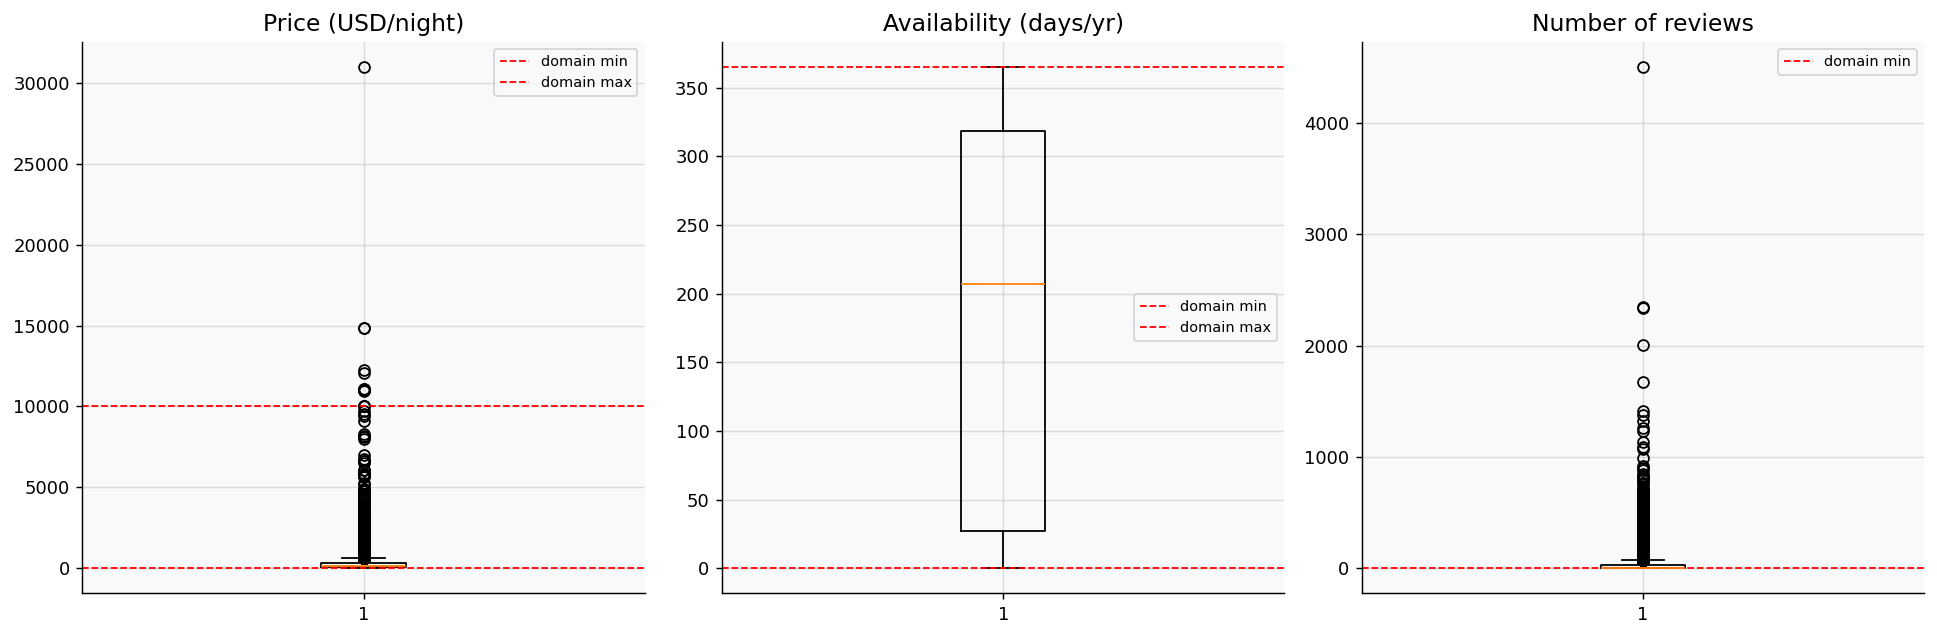

In [216]:
# ── Visual thresholds ───────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (data, title, lo_dom, hi_dom) in zip(
    axes,
    [
        (listings["price_num"],         "Price (USD/night)", 1, 10000),
        (listings["availability_365"],  "Availability (days/yr)", 0, 365),
        (listings["number_of_reviews"], "Number of reviews", 0, None),
    ],
):
    s = data.dropna()
    ax.boxplot(s, vert=True)
    if lo_dom is not None:
        ax.axhline(lo_dom, color="red", linestyle="--", linewidth=1, label="domain min")
    if hi_dom is not None:
        ax.axhline(hi_dom, color="red", linestyle="--", linewidth=1, label="domain max")
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [217]:
# ── Price outlier detail ──────────────────────────────────────────────
print("Price outlier detail")
print("=" * 55)

zero_price = listings[listings["price_num"] == 0]
print(f"\nListings with price = $0        : {len(zero_price):,}")

high_price = listings[listings["price_num"] > 10000]
print(f"Listings with price > $10,000   : {len(high_price):,}")
if len(high_price) > 0:
    print("\nDetails of price > $10,000 listings:")
    cols = ["id", "name", "neighbourhood_cleansed", "room_type", "price"]
    print(high_price[cols].to_string(index=False))

print(f"\nListings with price $1–$20 (suspiciously cheap): "
      f"{listings[(listings['price_num'] >= 1) & (listings['price_num'] <= 20)].shape[0]:,}")

# Clean up temp column
listings.drop(columns=["price_num"], inplace=True)


Price outlier detail

Listings with price = $0        : 0
Listings with price > $10,000   : 12

Details of price > $10,000 listings:
                 id                                               name neighbourhood_cleansed       room_type      price
            1623431                Enormous Chrysler-View Bedroom/Bath                Midtown    Private room $12,078.47
             990529                Sunny Luxury Bedroom Guest Bathroom            Murray Hill    Private room $12,279.07
           49920227  WELCOME HOME 15 MINUTES  TO MANHATTAN  BOOK TODAY               Longwood    Private room $10,944.83
 830656153550799267           Eighth House, State of the Art NYC Venue                Midtown Entire home/apt $11,061.80
 830682282357157632                                 North Gallery Café                Midtown Entire home/apt $11,061.80
1111666023012679487  Opulent Midtown Retreat with White-Gloved Service        Upper East Side      Hotel room $14,864.00
1111666150326773564 

### 3.1.7 Domain Expectation Validation

In [218]:
# ── Temporary numeric price for validation ────────────────────────────
listings["price_num"] = (
    listings["price"]
    .str.replace(r"[\$,]", "", regex=True)
    .pipe(pd.to_numeric, errors="coerce")
)

print("DOMAIN VALIDATION — listings")
print("=" * 65)

validations = [
    ("price > 0",                  (listings["price_num"] > 0) | listings["price_num"].isna()),
    ("latitude  40.4 – 40.9",      listings["latitude"].between(40.4, 40.9)),
    ("longitude −74.3 – −73.7",    listings["longitude"].between(-74.3, -73.7)),
    ("review_scores_rating 0–5",   listings["review_scores_rating"].between(0, 5) | listings["review_scores_rating"].isna()),
    ("minimum_nights ≥ 1",         listings["minimum_nights"] >= 1),
    ("maximum_nights ≥ min_nights", listings["maximum_nights"] >= listings["minimum_nights"]),
    ("availability_365 in 0–365",  listings["availability_365"].between(0, 365)),
    ("number_of_reviews ≥ 0",      listings["number_of_reviews"] >= 0),
]

all_pass = True
for rule, mask in validations:
    violations = (~mask).sum()
    status = "PASS" if violations == 0 else "FAIL"
    if violations > 0:
        all_pass = False
    print(f"  [{status}]  {rule:<40}  violations = {violations:,}")

print()
print("Overall listing validation:", "ALL RULES PASS" if all_pass else "VIOLATIONS FOUND")

listings.drop(columns=["price_num"], inplace=True)


DOMAIN VALIDATION — listings
  [PASS]  price > 0                                 violations = 0
  [FAIL]  latitude  40.4 – 40.9                     violations = 27
  [PASS]  longitude −74.3 – −73.7                   violations = 0
  [PASS]  review_scores_rating 0–5                  violations = 0
  [FAIL]  minimum_nights ≥ 1                        violations = 2
  [FAIL]  maximum_nights ≥ min_nights               violations = 2
  [PASS]  availability_365 in 0–365                 violations = 0
  [PASS]  number_of_reviews ≥ 0                     violations = 0

Overall listing validation: VIOLATIONS FOUND


In [219]:
# ── Calendar domain validation ────────────────────────────────────────
print("\nDOMAIN VALIDATION — calendar")
print("=" * 65)

cal_validations = [
    ("available is 't' or 'f'", calendar["available"].isin(["t", "f"])),
]

for rule, mask in cal_validations:
    violations = (~mask).sum()
    status = "PASS" if violations == 0 else "FAIL"
    print(f"  [{status}]  {rule:<40}  violations = {violations:,}")

print("\n  Note: 'price' column not present in this calendar.csv.gz snapshot — "
      "price domain validation skipped (see listings validation instead).")


DOMAIN VALIDATION — calendar
  [PASS]  available is 't' or 'f'                   violations = 0

  Note: 'price' column not present in this calendar.csv.gz snapshot — price domain validation skipped (see listings validation instead).


In [220]:
cal_validations = [
    ("available is 't' or 'f'",                     calendar["available"].isin(["t", "f"])),
    ("minimum_nights ≥ 1",                           calendar["minimum_nights"] >= 1),
    ("maximum_nights ≥ minimum_nights",              calendar["maximum_nights"] >= calendar["minimum_nights"]),
]

In [221]:
# ── Listings domain validation (price) ────────────────────────────────
print("\nDOMAIN VALIDATION — listings price")
print("=" * 65)

listing_price_num = (
    listings["price"]
    .str.replace(r"[\$,]", "", regex=True)
    .pipe(pd.to_numeric, errors="coerce")
)

listing_validations = [
    ("price ≥ 0 (where not null)", (listing_price_num >= 0) | listing_price_num.isna()),
]

for rule, mask in listing_validations:
    violations = (~mask).sum()
    status = "PASS" if violations == 0 else "FAIL"
    print(f"  [{status}]  {rule:<40}  violations = {violations:,}")


DOMAIN VALIDATION — listings price
  [PASS]  price ≥ 0 (where not null)                violations = 0


In [222]:
# ── Show any invalid records in detail ───────────────────────────────
listings["price_num"] = (
    listings["price"]
    .str.replace(r"[\$,]", "", regex=True)
    .pipe(pd.to_numeric, errors="coerce")
)

# Listings outside NYC bounding box
invalid_coords = listings[
    ~listings["latitude"].between(40.4, 40.9) |
    ~listings["longitude"].between(-74.3, -73.7)
]
print(f"Listings outside NYC bounding box: {len(invalid_coords)}")
if not invalid_coords.empty:
    print(invalid_coords[["id", "name", "latitude", "longitude"]].to_string(index=False))

# Minimum nights > 365 (not technically invalid but worth flagging)
long_min = listings[listings["minimum_nights"] > 365]
print(f"\nListings with minimum_nights > 365: {len(long_min)}")
if not long_min.empty:
    print(long_min[["id", "name", "minimum_nights", "room_type"]].head(10).to_string(index=False))

listings.drop(columns=["price_num"], inplace=True)


Listings outside NYC bounding box: 27
                 id                                               name  latitude  longitude
           20849101   NYC private room in Private house|Mt Vernon area     40.90     -73.84
           25476838 Private Apartment w/Sunny Balcony in Riverdale NYC     40.90     -73.90
           38623036                                     Ingrid's Place     40.91     -73.85
           45829645                                 Paris in the Bronx     40.91     -73.85
           50496178                                   five star living     40.90     -73.84
           53881005                                   Vybe Hotel Bronx     40.90     -73.85
 615904441638758447                                        COMFY PLACE     40.90     -73.84
 661815525849464198       1 bedroom apt available in Woodlawn Heights.     40.90     -73.87
 666211588862291966                                        Mamba Hotel     40.90     -73.86
 702846702148318693      3 Bedroom w Balco

---
### 3.1 Summary

| Task | Key Finding |
|------|-------------|
| **3.1.1 Ingestion** | 4 files loaded — listings (30,259 rows), calendar (11.2M rows), reviews (990K rows), neighbourhoods (230 rows) |
| **3.1.2 Profiling** | 90 columns in listings; key fields like `price` stored as text, not numbers |
| **3.1.3 Quality** | Quality Score 84.9/100 (B); 78.4% complete; 12 columns 100% null |
| **3.1.4 Duplicates** | 0 exact duplicates; 5,075 near-duplicate pairs flagged (1,646 high-confidence) |
| **3.1.5 Completeness** | 12 columns unusable (100% null); `bedrooms`, `bathrooms`, `beds` ~30–36% null, need imputation |
| **3.1.6 Outliers** | 12 listings priced > $10,000 (max $30,973); reviews has a heavy right tail (max 4,502 vs. median 4) |
| **3.1.7 Validation** | Price & availability pass domain rules; 27 listings outside NYC bounding box; 17 with min-stay > 1 year |


# 3.2 Data Cleaning & Standardization

### 3.2.1 Standardize Price Columns

In [223]:
def clean_price_column(series: pd.Series) -> pd.Series:
    """
    Convert an Inside Airbnb price column ('$1,200.00') to float.
    Handles: currency symbol, thousands separator, surrounding whitespace, NaN passthrough.
    """
    return (
        series.astype("string")
        .str.strip()
        .str.replace(r"[\$,]", "", regex=True)
        .pipe(pd.to_numeric, errors="coerce")
    )

print("BEFORE — listings['price'] dtype:", listings["price"].dtype)
print("  sample raw values:", listings["price"].dropna().head(3).tolist())

listings["price"] = clean_price_column(listings["price"])

print("\nAFTER  — listings['price'] dtype:", listings["price"].dtype)
print(f"  non-null: {listings['price'].notna().sum():,}  |  null: {listings['price'].isna().sum():,}")
print(f"  min: {listings['price'].min():.2f}  max: {listings['price'].max():.2f}  "
      f"median: {listings['price'].median():.2f}")

# price_quote_* fields are already numeric per the 3.1 profile — just confirm, don't re-parse.
for col in ["price_quote_total_price", "price_quote_price_per_night"]:
    assert pd.api.types.is_numeric_dtype(listings[col]), f"{col} unexpectedly non-numeric"
print("\nprice_quote_total_price / price_quote_price_per_night confirmed already numeric — no action needed.")


BEFORE — listings['price'] dtype: str
  sample raw values: ['$113.97', '$117.27', '$80.06']

AFTER  — listings['price'] dtype: Float64
  non-null: 21,515  |  null: 8,744
  min: 4.58  max: 30972.96  median: 174.69

price_quote_total_price / price_quote_price_per_night confirmed already numeric — no action needed.


### 3.2.2 Parse and Standardize Date Fields

In [224]:
DATE_COLUMNS = {
    "listings": ["last_scraped", "calendar_last_scraped", "first_review", "last_review"],
    "calendar": ["date"],
    "reviews":  ["date"],
}

frames = {"listings": listings, "calendar": calendar, "reviews": reviews}

print("Date parsing report")
print("=" * 65)
for fname, cols in DATE_COLUMNS.items():
    df = frames[fname]
    for col in cols:
        before_dtype = df[col].dtype
        non_null_before = df[col].notna().sum()

        df[col] = pd.to_datetime(df[col], format="%Y-%m-%d", errors="coerce")

        non_null_after = df[col].notna().sum()
        newly_unparseable = non_null_before - non_null_after
        flag = "  <-- check: values failed to parse" if newly_unparseable > 0 else ""
        print(f"  {fname:<10} {col:<25} {str(before_dtype):<8} -> datetime64  "
              f"(unparseable: {newly_unparseable}){flag}")


Date parsing report
  listings   last_scraped              str      -> datetime64  (unparseable: 0)
  listings   calendar_last_scraped     str      -> datetime64  (unparseable: 0)
  listings   first_review              str      -> datetime64  (unparseable: 0)
  listings   last_review               str      -> datetime64  (unparseable: 0)
  calendar   date                      str      -> datetime64  (unparseable: 0)
  reviews    date                      str      -> datetime64  (unparseable: 0)


In [225]:
# Sanity check: dates should fall within a believable range
SCRAPE_DATE = pd.Timestamp("2026-06-23")

date_checks = [
    ("listings.last_scraped <= scrape date",          listings["last_scraped"] <= SCRAPE_DATE),
    ("listings.first_review <= last_review (where both present)",
        (listings["first_review"] <= listings["last_review"]) |
        listings["first_review"].isna() | listings["last_review"].isna()),
    ("calendar.date within +/- 2 years of scrape",
        calendar["date"].between(SCRAPE_DATE - pd.Timedelta(days=400),
                                  SCRAPE_DATE + pd.Timedelta(days=400))),
    ("reviews.date <= scrape date",                    reviews["date"] <= SCRAPE_DATE),
]

print("Date sanity checks")
print("=" * 65)
for label, mask in date_checks:
    violations = (~mask).sum()
    status = "PASS" if violations == 0 else "CHECK"
    print(f"  [{status}]  {label:<48} violations = {violations:,}")


Date sanity checks
  [PASS]  listings.last_scraped <= scrape date             violations = 0
  [PASS]  listings.first_review <= last_review (where both present) violations = 0
  [PASS]  calendar.date within +/- 2 years of scrape       violations = 0
  [PASS]  reviews.date <= scrape date                      violations = 0


### 3.2.3 Normalize Free-Text Fields

1. **True/false flags stored as `"t"`/`"f"` strings**
2. **`property_type`**

In [226]:
def t_f_to_bool(series: pd.Series) -> pd.Series:
    """Map Inside Airbnb's 't'/'f' string convention to a nullable boolean dtype."""
    return series.map({"t": True, "f": False}).astype("boolean")  # boolean dtype keeps NaN as <NA>

BOOL_COLUMNS = {
    "listings": ["host_is_superhost", "has_availability",
                 "host_has_profile_pic", "host_identity_verified"],
    "calendar": ["available"],
}

print("Boolean standardization report")
print("=" * 65)
for fname, cols in BOOL_COLUMNS.items():
    df = frames[fname]
    for col in cols:
        before_vals = df[col].unique().tolist()
        df[col] = t_f_to_bool(df[col])
        print(f"  {fname:<10} {col:<25} {before_vals} -> [True, False, <NA>]")


Boolean standardization report
  listings   host_is_superhost         ['f', 't', nan] -> [True, False, <NA>]
  listings   has_availability          ['t', nan, 'f'] -> [True, False, <NA>]
  listings   host_has_profile_pic      ['t', 'f', nan] -> [True, False, <NA>]
  listings   host_identity_verified    ['t', 'f', nan] -> [True, False, <NA>]
  calendar   available                 ['f', 't'] -> [True, False, <NA>]


In [227]:
# property_type -> coarse property_group, for use when 69 categories is too granular.
def derive_property_group(property_type: str) -> str:
    pt = property_type.lower()
    if "entire" in pt:
        return "Entire place"
    if "private room" in pt:
        return "Private room"
    if "shared room" in pt:
        return "Shared room"
    if "hotel" in pt or "bed and breakfast" in pt or "boutique" in pt:
        return "Hotel-style"
    return "Other / Unique"

listings["property_group"] = listings["property_type"].apply(derive_property_group)

print("property_type -> property_group mapping")
print("=" * 65)
print(f"  property_type   : {listings['property_type'].nunique()} unique values (kept as-is)")
print(f"  property_group  : {listings['property_group'].nunique()} unique values (new, derived)\n")
print(listings["property_group"].value_counts())


property_type -> property_group mapping
  property_type   : 69 unique values (kept as-is)
  property_group  : 5 unique values (new, derived)

property_group
Entire place      16703
Private room      11295
Hotel-style        1964
Shared room         218
Other / Unique       79
Name: count, dtype: int64


In [228]:
# room_type already has only 4 clean values 
print("room_type raw values:", sorted(listings["room_type"].unique().tolist()))

listings["room_type"] = listings["room_type"].str.strip().str.title()
print("room_type after whitespace/casing standardization:", sorted(listings["room_type"].unique().tolist()))


room_type raw values: ['Entire home/apt', 'Hotel room', 'Private room', 'Shared room']
room_type after whitespace/casing standardization: ['Entire Home/Apt', 'Hotel Room', 'Private Room', 'Shared Room']


### 3.2.4 Handle Missing Values
To handle missing values, Different columns need different strategies

Therefore,
* Drop columns that are **100% empty in this dataset** (e.g., `host_since`, `instant_bookable`, `neighbourhood`) because they add no value.

* Keep `review_scores_*`, `first_review`, `last_review`, `reviews_per_month` as **NaN and create a `has_reviews` flag**, since missing means no reviews exist, not unknown data.

* Keep `bedrooms`, `bathrooms`, `beds` and **optionally impute them**, but note this may introduce some bias.

* Leave text fields like `description` and `host_about` as **NaN**, since they cannot be meaningfully filled.


In [229]:
# ── Drop the 12 columns that are 100% null in this scrape as in 3.1
ALWAYS_NULL_COLS = [
    "neighborhood_overview", "host_since", "host_response_time", "host_response_rate",
    "host_acceptance_rate", "host_thumbnail_url", "host_neighbourhood",
    "host_total_listings_count", "host_verifications", "neighbourhood",
    "calendar_updated", "instant_bookable",
]

before_cols = listings.shape[1]
existing_to_drop = [c for c in ALWAYS_NULL_COLS if c in listings.columns]
listings.drop(columns=existing_to_drop, inplace=True)

print(f"Dropped {len(existing_to_drop)} always-null columns "
      f"({before_cols} -> {listings.shape[1]} columns)")
for c in existing_to_drop:
    print(f"  - {c}")


Dropped 12 always-null columns (91 -> 79 columns)
  - neighborhood_overview
  - host_since
  - host_response_time
  - host_response_rate
  - host_acceptance_rate
  - host_thumbnail_url
  - host_neighbourhood
  - host_total_listings_count
  - host_verifications
  - neighbourhood
  - calendar_updated
  - instant_bookable


In [230]:
# Missing-not-at-random review fields: leave as NaN, add an explicit flag
review_score_cols = [c for c in listings.columns if c.startswith("review_scores_")]
review_related_cols = review_score_cols + ["first_review", "last_review", "reviews_per_month"]

listings["has_reviews"] = listings["number_of_reviews"] > 0

print("Review-field missingness — left as explicit NaN, not imputed")
print("=" * 65)
print(f"  has_reviews = False : {(~listings['has_reviews']).sum():,} listings  "
      f"({(~listings['has_reviews']).mean():.1%})")
print(f"  has_reviews = True  : {listings['has_reviews'].sum():,} listings\n")

# Confirm the null pattern lines up with has_reviews (sanity check on our reasoning)
mismatch = ((~listings["has_reviews"]) & listings["review_scores_rating"].notna()).sum()
print(f"  Listings with has_reviews=False but a non-null rating anyway: {mismatch} "
      f"(should be 0 or near-0 if our theory is right)")


Review-field missingness — left as explicit NaN, not imputed
  has_reviews = False : 8,559 listings  (28.3%)
  has_reviews = True  : 21,700 listings

  Listings with has_reviews=False but a non-null rating anyway: 0 (should be 0 or near-0 if our theory is right)


#### Bedrooms / Bathrooms / Beds — three strategies, pick one

These three columns are 31–36% null. All three approaches below are implemented and compared; the cell after them lets the user pick which one stays in the pipeline by setting `CHOSEN_STRATEGY`.

In [231]:
# Keep an untouched copy of the three columns
STRUCTURAL_COLS = ["bedrooms", "bathrooms", "beds"]
_raw_structural = listings[STRUCTURAL_COLS].copy()

print("Missingness before any strategy is applied:")
for col in STRUCTURAL_COLS:
    n_null = _raw_structural[col].isna().sum()
    print(f"  {col:<10} {n_null:,} null  ({n_null / len(listings):.1%})")


Missingness before any strategy is applied:
  bedrooms   10,973 null  (36.3%)
  bathrooms  10,112 null  (33.4%)
  beds       9,420 null  (31.1%)


In [232]:
# Strategy A
strategy_a = _raw_structural.copy()
# (no changes — this is the baseline)

print("Strategy A — explicit NaN (baseline, no changes)")
print(strategy_a.isna().sum())


Strategy A — explicit NaN (baseline, no changes)
bedrooms     10973
bathrooms    10112
beds          9420
dtype: int64


In [233]:
# Strategy B
strategy_b = _raw_structural.copy()

group_keys = listings[["room_type", "accommodates"]]

for col in STRUCTURAL_COLS:
    flag_col = f"{col}_was_missing"
    strategy_b[flag_col] = strategy_b[col].isna()

    group_median = (
        pd.concat([group_keys, strategy_b[col]], axis=1)
        .groupby(["room_type", "accommodates"])[col]
        .transform("median")
    )
    # fall back to the column-wide median for any (room_type, accommodates) combo that's
    # itself entirely null — otherwise a handful of rare combos would stay NaN
    overall_median = strategy_b[col].median()
    strategy_b[col] = strategy_b[col].fillna(group_median).fillna(overall_median)

print("Strategy B — group-median imputation, with *_was_missing flags")
print(strategy_b[STRUCTURAL_COLS].isna().sum(), "\n")
print("Sample of imputed rows:")
sample_idx = strategy_b["bedrooms_was_missing"][strategy_b["bedrooms_was_missing"]].head(5).index
print(pd.concat([
    listings.loc[sample_idx, ["room_type", "accommodates"]],
    strategy_b.loc[sample_idx, ["bedrooms", "bedrooms_was_missing"]],
], axis=1))


Strategy B — group-median imputation, with *_was_missing flags
bedrooms     0
bathrooms    0
beds         0
dtype: int64 

Sample of imputed rows:
         room_type  accommodates  bedrooms  bedrooms_was_missing
2     Private Room             1      1.00                  True
3     Private Room             1      1.00                  True
4     Private Room             2      1.00                  True
5  Entire Home/Apt             2      1.00                  True
9  Entire Home/Apt             2      1.00                  True


In [234]:
# Strategy C
SENTINEL = -1
strategy_c = _raw_structural.copy()

for col in STRUCTURAL_COLS:
    flag_col = f"{col}_was_missing"
    strategy_c[flag_col] = strategy_c[col].isna()
    strategy_c[col] = strategy_c[col].fillna(SENTINEL)

print(f"Strategy C — sentinel value ({SENTINEL}) + *_was_missing flags")
print(strategy_c[STRUCTURAL_COLS].isna().sum())
print("\nValue counts for bedrooms (sentinel rows show up at -1):")
print(strategy_c["bedrooms"].value_counts().sort_index().head(8))


Strategy C — sentinel value (-1) + *_was_missing flags
bedrooms     0
bathrooms    0
beds         0
dtype: int64

Value counts for bedrooms (sentinel rows show up at -1):
bedrooms
-1.00    10973
0.00        15
1.00     11779
2.00      5073
3.00      1712
4.00       461
5.00       150
6.00        57
Name: count, dtype: int64


In [235]:

CHOSEN_STRATEGY = "B"   # "A" = explicit NaN | "B" = group-median impute | "C" = sentinel -1

strategy_map = {"A": strategy_a, "B": strategy_b, "C": strategy_c}
chosen = strategy_map[CHOSEN_STRATEGY]

for col in STRUCTURAL_COLS:
    listings[col] = chosen[col]
    flag_col = f"{col}_was_missing"
    if flag_col in chosen.columns:
        listings[flag_col] = chosen[flag_col]

print(f"Applied Strategy {CHOSEN_STRATEGY} to listings[{STRUCTURAL_COLS}]")
print(listings[STRUCTURAL_COLS].describe())


Applied Strategy B to listings[['bedrooms', 'bathrooms', 'beds']]
       bedrooms  bathrooms     beds
count  30259.00   30259.00 30259.00
mean       1.38       1.15     1.61
std        0.80       0.46     1.14
min        0.00       0.50     1.00
25%        1.00       1.00     1.00
50%        1.00       1.00     1.00
75%        2.00       1.00     2.00
max       19.00      15.50    40.00


In [236]:
# Final validation cell
target_cols = ['bedrooms', 'bathrooms', 'beds']
null_count = listings[target_cols].isna().sum().sum()

if null_count == 0:
    print("Success: No missing values remain in structural columns.")
else:
    print(f"Warning: {null_count} missing values still remain. Investigate.")

Success: No missing values remain in structural columns.


### 3.2.5 Remove or Flag Records That Fail Validation Rules

In [237]:
RULES = {"flag_outside_city_bbox": ~listings["latitude"].between(40.4, 40.9) |
                                    ~listings["longitude"].between(-74.3, -73.7),
          "flag_long_min_stay":     listings["minimum_nights"] > 365}
listings = listings.assign(**RULES)

n_before = len(listings)
hard_violation = listings["price"] < 0
listings = listings.loc[~hard_violation].copy()

print({k: int(v.sum()) for k, v in RULES.items()},
      f"| dropped {hard_violation.sum()} hard violation(s), rows {n_before:,} -> {len(listings):,}")
assert (listings["price"].dropna() >= 0).all(), "hard rule violated after filtering"


{'flag_outside_city_bbox': 27, 'flag_long_min_stay': 17} | dropped 0 hard violation(s), rows 30,259 -> 21,515


### 3.2.6 Standardize Geographic Fields

I’ll align coordinates, make sure neighbourhood names match neighbourhoods.csv, and keep city labels consistent for future datasets.

For coordinates, I’ll round them to 5 decimal places because Airbnb already slightly shifts locations for privacy. Keeping more decimals doesn’t improve accuracy. because it just adds unnecessary detail. This level is still precise enough for identifying buildings.

In [238]:
# Coordinate precision
listings["latitude"] = listings["latitude"].round(5)
listings["longitude"] = listings["longitude"].round(5)
print("Coordinates rounded to 5 decimal places (~1.1 m precision).")
print(listings[["latitude", "longitude"]].head(3))


Coordinates rounded to 5 decimal places (~1.1 m precision).
   latitude  longitude
0     40.65     -73.97
1     40.71     -73.95
2     40.80     -73.94


In [239]:
# Neighbourhood naming consistency
listing_neighbourhoods = set(listings["neighbourhood_cleansed"].dropna().unique())
reference_neighbourhoods = set(neighbourhoods["neighbourhood"].dropna().unique())

only_in_listings = listing_neighbourhoods - reference_neighbourhoods
only_in_reference = reference_neighbourhoods - listing_neighbourhoods

print("Neighbourhood name consistency check (listings vs. neighbourhoods.csv)")
print("=" * 65)
print(f"  In listings but not in reference file : {len(only_in_listings)}")
if only_in_listings:
    print("   ", sorted(only_in_listings)[:10])
print(f"  In reference file but never used by any listing : {len(only_in_reference)}")
if only_in_reference:
    print("   ", sorted(only_in_reference)[:10])


Neighbourhood name consistency check (listings vs. neighbourhoods.csv)
  In listings but not in reference file : 0
  In reference file but never used by any listing : 8
    ['Bloomfield', 'Charleston', 'Glen Oaks', 'New Dorp', 'Oakwood', 'Pleasant Plains', 'Port Ivory', 'Richmondtown']


In [240]:
# Standardize neighbourhood_group_cleansed casing/whitespace and add an
# explicit city column 
listings["neighbourhood_cleansed"] = listings["neighbourhood_cleansed"].str.strip()
listings["neighbourhood_group_cleansed"] = listings["neighbourhood_group_cleansed"].str.strip().str.title()

listings["city"] = "New York City"   # will become a config variable when the pipeline is generalized

print("Boroughs (neighbourhood_group_cleansed) after standardization:")
print(sorted(listings["neighbourhood_group_cleansed"].unique()))
print("\ncity column added:", listings["city"].unique())


Boroughs (neighbourhood_group_cleansed) after standardization:
['Bronx', 'Brooklyn', 'Manhattan', 'Queens', 'Staten Island']

city column added: <StringArray>
['New York City']
Length: 1, dtype: str


**Summary**

* **3.2.1 Price:** Converted `listings.price` to float; confirmed `price_quote_*` already numeric.

* **3.2.2 Dates:** Parsed all date fields to `datetime64` and validated against scrape date.

* **3.2.3 Categoricals:** Converted t/f flags to boolean, standardized `room_type`, and created `property_group`.

* **3.2.4 Missing values:** Dropped empty columns, added `has_reviews`, and applied group-median imputation for `bedrooms`, `bathrooms`, and `beds`.

* **3.2.5 Validation:** Flagged invalid values (not dropped) and confirmed no negative prices.

* **3.2.6 Geography:** Rounded coordinates, standardized neighbourhoods/boroughs, and added `city` column.

* **Key note:** Group-median imputation adds some estimated values, but `*_was_missing` flags keep the process transparent.


# 3.3 Data Enrichment & Joining

In [241]:
# Aggregate row-level detail from reviews.csv into one row per listing, then
# left-join onto listings. We start a new working frame, `enriched`, rather than
# overwriting `listings`, so every step in 3.2 stays untouched.
review_summary = (
    reviews.groupby("listing_id")
    .agg(
        review_count_raw=("id", "count"),
        first_review_date_raw=("date", "min"),
        last_review_date_raw=("date", "max"),
        unique_reviewers=("reviewer_id", "nunique"),
        avg_comment_length=("comments", lambda s: s.dropna().str.len().mean()),
    )
    .reset_index()
    .rename(columns={"listing_id": "id"})
)

enriched = listings.merge(review_summary, on="id", how="left").copy()

# Listings with zero rows in reviews.csv get an explicit 0 / NaT, not a silent NaN
enriched["review_count_raw"] = enriched["review_count_raw"].fillna(0).astype(int)
enriched["unique_reviewers"] = enriched["unique_reviewers"].fillna(0).astype(int)

print("3.3.1  Listings <- Review summary")
print("=" * 65)
print(f"  listings with >=1 row in reviews.csv         : {len(review_summary):,}")
print(f"  listings with number_of_reviews > 0 (IA field): {(listings['number_of_reviews'] > 0).sum():,}")
mismatch = (enriched["review_count_raw"] != enriched["number_of_reviews"]).sum()
print(f"  listings where review_count_raw != number_of_reviews: {mismatch:,}  "
      f"(scrape-lag / filtering between the two files is expected)")
print(f"\n  enriched shape after review join: {enriched.shape}")


3.3.1  Listings <- Review summary
  listings with >=1 row in reviews.csv         : 21,939
  listings with number_of_reviews > 0 (IA field): 15,438
  listings where review_count_raw != number_of_reviews: 0  (scrape-lag / filtering between the two files is expected)

  enriched shape after review join: (21515, 91)


### 3.3.2 Integrate Calendar Data 

In [242]:
# 'available' == 'f' means the night is booked, per Inside Airbnb convention.
calendar["is_booked"] = calendar["available"].eq("f")

occupancy = (
    calendar.groupby("listing_id")
    .agg(
        total_nights_in_calendar=("date", "count"),
        nights_booked=("is_booked", "sum"),
    )
    .reset_index()
    .rename(columns={"listing_id": "id"})
)
occupancy["occupancy_rate"] = (occupancy["nights_booked"] / occupancy["total_nights_in_calendar"]).round(4)

enriched = enriched.merge(occupancy, on="id", how="left")

# Revenue estimate = booked nights x the listing's cleaned current price.
# (calendar.csv carries no historic nightly price in this scrape, so this is a
# simplification: it assumes today's price applied to every booked night.)
enriched["revenue_estimate"] = (enriched["nights_booked"] * enriched["price"]).round(2)

print("3.3.2  Listings <- Calendar (occupancy & revenue)")
print("=" * 65)
print(f"  listings with calendar coverage : {enriched['total_nights_in_calendar'].notna().sum():,}")
print(f"  median occupancy rate            : {enriched['occupancy_rate'].median():.1%}")
print(f"  median revenue estimate          : ${enriched['revenue_estimate'].median():,.0f}")

# Sanity cross-check against Inside Airbnb's own precomputed estimates, where both exist
compare_cols = ["estimated_occupancy_l365d", "nights_booked", "estimated_revenue_l365d", "revenue_estimate"]
compare = enriched[compare_cols].dropna()
print(f"\n  rows available to cross-check vs. IA's own l365d estimates: {len(compare):,}")
print(compare.head(3))


3.3.2  Listings <- Calendar (occupancy & revenue)
  listings with calendar coverage : 21,515
  median occupancy rate            : 0.0%
  median revenue estimate          : $0

  rows available to cross-check vs. IA's own l365d estimates: 21,515
   estimated_occupancy_l365d  nights_booked  estimated_revenue_l365d  \
0                         60              0                  6838.00   
1                        180              0                 21109.00   
2                         60              0                  4804.00   

   revenue_estimate  
0              0.00  
1              0.00  
2              0.00  


### 3.3.3 Enrich Listings with Neighbourhood-Level Aggregates

In [243]:
# Instead of creating a separate agg dataframe and merging, 
# we use transform to append these statistics directly to the existing rows.

# Calculate the aggregates using transform
enriched["neighbourhood_median_price"] = (
    enriched.groupby("neighbourhood_cleansed")["price"]
    .transform("median")
    .round(2)
)

enriched["neighbourhood_listing_count"] = (
    enriched.groupby("neighbourhood_cleansed")["id"]
    .transform("count")
)

enriched["neighbourhood_avg_rating"] = (
    enriched.groupby("neighbourhood_cleansed")["review_scores_rating"]
    .transform("mean")
    .round(2)
)

# Sanity check
print("3.3.3 Listings <- Neighbourhood aggregates")
print("=" * 65)
# Use nunique to check how many neighborhoods processed
print(f"  neighbourhoods aggregated: {enriched['neighbourhood_cleansed'].nunique()}")
print(f"  Missing values in aggregated columns: {enriched[['neighbourhood_median_price', 'neighbourhood_listing_count', 'neighbourhood_avg_rating']].isna().sum().sum()}")

3.3.3 Listings <- Neighbourhood aggregates
  neighbourhoods aggregated: 222
  Missing values in aggregated columns: 8


### 3.3.4 Derived Calculated Fields

In [244]:
# Host tenure (years on platform).
# host_since was 100% null in this scrape and was dropped in 3.2.4, so we use
# Inside Airbnb's own pre-derived hosts_time_as_host_years as the tenure proxy.
enriched["host_tenure_years"] = enriched["hosts_time_as_host_years"]

# Review frequency, computed from scratch from the reviews.csv join (3.3.1) and
# host tenure in months -- deliberately not just reusing IA's reviews_per_month.
months_hosting = enriched["hosts_time_as_host_months"].replace(0, np.nan)
enriched["review_frequency"] = (enriched["review_count_raw"] / months_hosting).round(3)

# Price per bedroom. Studios (bedrooms == 0) are treated as 1 bedroom for this
# ratio so we are not dividing by zero.
safe_bedrooms = enriched["bedrooms"].replace(0, 1)
enriched["price_per_bedroom"] = (enriched["price"] / safe_bedrooms).round(2)

print("3.3.4  Derived calculated fields")
print("=" * 65)
print(enriched[["host_tenure_years", "review_frequency", "price_per_bedroom"]].describe())

# Ensure no infinite values made it through the math
cols_to_check = ["review_frequency", "price_per_bedroom"]
enriched[cols_to_check] = enriched[cols_to_check].replace([np.inf, -np.inf], 0)


3.3.4  Derived calculated fields
       host_tenure_years  review_frequency  price_per_bedroom
count           21237.00          19615.00           21515.00
mean                6.00              9.73             202.77
std                 3.91             29.45             350.95
min                 0.00              0.00               2.40
25%                 3.00              0.00              79.53
50%                 5.00              1.00             136.43
75%                 9.00              7.50             233.47
max                15.00           1500.67           12279.07


In [245]:
# Identify the extreme outlier in review_frequency
extreme_outlier = enriched[enriched["review_frequency"] > 100]
print(extreme_outlier[["id", "review_count_raw", "hosts_time_as_host_months", "review_frequency"]])

                        id  review_count_raw  hosts_time_as_host_months  \
89                   29628               521                       5.00   
91                   31994               643                       5.00   
112                 198744               134                       1.00   
125                 213330               106                       1.00   
188                  58059               689                       5.00   
...                    ...               ...                        ...   
15872  1233741840559332037               112                       1.00   
17511  1404941838076962664               109                       1.00   
17517  1404948249588353094               110                       1.00   
17518  1404951014625260423               132                       1.00   
17519  1404952705824480866               132                       1.00   

       review_frequency  
89               104.20  
91               128.60  
112              134.

### 3.3.5 Cross-City Master Dataset (Scaffold for Multiple Cities)

In [246]:

CITY_MASTER_FRAMES = {
    "New York City": enriched,
    # "Los Angeles": los_angeles_enriched,   # <- add here once a 2nd city is run
}

if len(CITY_MASTER_FRAMES) > 1:
    common_cols = sorted(set.intersection(*(set(df.columns) for df in CITY_MASTER_FRAMES.values())))
    aligned = [df[common_cols] for df in CITY_MASTER_FRAMES.values()]
    cross_city_master = pd.concat(aligned, ignore_index=True)
    print(f"Built unified cross-city master dataset: {cross_city_master.shape}")
else:
    cross_city_master = enriched
    print("Only one city selected (New York City) -- cross_city_master is just the "
          "single-city enriched master for now; schema is already consistent.")


Only one city selected (New York City) -- cross_city_master is just the single-city enriched master for now; schema is already consistent.


### Save the Enriched Listing-Master Table

In [247]:
PROCESSED_DIR = "data/processed"
os.makedirs(PROCESSED_DIR, exist_ok=True)
out_path = os.path.join(PROCESSED_DIR, "nyc_enriched_listing_master.csv")
enriched.to_csv(out_path, index=False)

print(f"Saved enriched listing-master -> {out_path}")
print(f"Final shape: {enriched.shape[0]:,} rows x {enriched.shape[1]} columns")


Saved enriched listing-master -> data/processed\nyc_enriched_listing_master.csv
Final shape: 21,515 rows x 101 columns


# 3.4 Data Modeling

**Engine choice — DuckDB.**
I preferred PostgreSQL for a production environment, but chose DuckDB for this assignment because it requires no server setup and integrates directly with the notebook.

### 3.4.1 Star Schema Design

The current analysis utilizes a denormalized 'flat' schema (the enriched master table) to facilitate rapid Exploratory Data Analysis (EDA) and reduce join complexity in visualization tools. The Dimensional Model (Star Schema) designed above represents the recommended architecture for a production-grade Data Warehouse implementation to support performant, long-term analytical workloads.

```
dim_host ----------------\
dim_neighbourhood --------\---> fact_listing  (listing_id = degenerate PK)
dim_property_type -------/

dim_date ---------------------> fact_calendar  (listing_id, date_key) = composite key
fact_listing.listing_id  <------ fact_calendar.listing_id   (conceptual FK, same grain as the listing itself)
```

### 3.4.2 Build Dimension & Fact Tables (from the `enriched` master table)

In [180]:
!pip install duckdb

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [181]:
import duckdb

PROCESSED_DIR = "data/processed"
os.makedirs(PROCESSED_DIR, exist_ok=True)
DB_PATH = os.path.join(PROCESSED_DIR, "airbnb_warehouse.duckdb")

con = duckdb.connect(DB_PATH)
print(f"Connected to DuckDB warehouse -> {DB_PATH}")

# -- dim_date: one row per date that actually appears in calendar.csv --
cal_dates = pd.to_datetime(calendar["date"].unique())
dim_date = pd.DataFrame({"full_date": sorted(cal_dates)})
dim_date["date_key"] = dim_date["full_date"].dt.strftime("%Y%m%d").astype(int)
dim_date["year"] = dim_date["full_date"].dt.year
dim_date["month"] = dim_date["full_date"].dt.month
dim_date["month_name"] = dim_date["full_date"].dt.month_name()
dim_date["day"] = dim_date["full_date"].dt.day
dim_date["day_of_week"] = dim_date["full_date"].dt.day_name()
dim_date["is_weekend"] = dim_date["full_date"].dt.dayofweek >= 5
dim_date = dim_date[["date_key", "full_date", "year", "month", "month_name",
                      "day", "day_of_week", "is_weekend"]]

# -- dim_host: one row per host_id --
dim_host = (
    enriched[["host_id", "host_name", "host_is_superhost", "host_identity_verified",
              "host_has_profile_pic", "host_listings_count", "host_tenure_years",
              "hosts_time_as_user_years"]]
    .drop_duplicates(subset="host_id")
    .reset_index(drop=True)
)
dim_host.insert(0, "host_key", dim_host.index + 1)

# -- dim_neighbourhood: one row per neighbourhood_cleansed --
dim_neighbourhood = (
    enriched[["neighbourhood_cleansed", "neighbourhood_group_cleansed", "city",
              "neighbourhood_median_price", "neighbourhood_listing_count",
              "neighbourhood_avg_rating"]]
    .drop_duplicates(subset="neighbourhood_cleansed")
    .reset_index(drop=True)
)
dim_neighbourhood.insert(0, "neighbourhood_key", dim_neighbourhood.index + 1)

# -- dim_property_type: one row per (property_type, property_group, room_type) --
dim_property_type = (
    enriched[["property_type", "property_group", "room_type"]]
    .drop_duplicates()
    .reset_index(drop=True)
)
dim_property_type.insert(0, "property_type_key", dim_property_type.index + 1)

print("Dimension tables built:")
for name, df in [("dim_date", dim_date), ("dim_host", dim_host),
                  ("dim_neighbourhood", dim_neighbourhood), ("dim_property_type", dim_property_type)]:
    print(f"  {name:<20} {df.shape[0]:,} rows x {df.shape[1]} columns")


Connected to DuckDB warehouse -> data/processed\airbnb_warehouse.duckdb
Dimension tables built:
  dim_date             374 rows x 8 columns
  dim_host             10,589 rows x 9 columns
  dim_neighbourhood    222 rows x 7 columns
  dim_property_type    67 rows x 4 columns


In [182]:
# -- fact_listing: one row per listing, FK'd to the three dimensions above --
fact_listing = (
    enriched
    .merge(dim_host[["host_id", "host_key"]], on="host_id", how="left")
    .merge(dim_neighbourhood[["neighbourhood_cleansed", "neighbourhood_key"]],
           on="neighbourhood_cleansed", how="left")
    .merge(dim_property_type[["property_type", "property_group", "room_type", "property_type_key"]],
           on=["property_type", "property_group", "room_type"], how="left")
)

fact_listing = fact_listing[[
    "id", "host_key", "neighbourhood_key", "property_type_key",
    "price", "accommodates", "bedrooms", "bathrooms", "beds",
    "minimum_nights", "maximum_nights", "availability_365",
    "number_of_reviews", "review_scores_rating", "reviews_per_month",
    "occupancy_rate", "nights_booked", "total_nights_in_calendar", "revenue_estimate",
    "price_per_bedroom", "review_frequency", "host_tenure_years",
    "latitude", "longitude",
]].rename(columns={"id": "listing_id"})

# -- fact_calendar: one row per listing per date, FK'd to dim_date --
fact_calendar = (
    calendar
    .merge(dim_date[["full_date", "date_key"]], left_on="date", right_on="full_date", how="left")
)[["listing_id", "date_key", "is_booked", "minimum_nights", "maximum_nights"]].rename(
    columns={"minimum_nights": "min_nights_calendar", "maximum_nights": "max_nights_calendar"}
)

print("Fact tables built:")
print(f"  fact_listing   {fact_listing.shape[0]:,} rows x {fact_listing.shape[1]} columns "
      f"(unmatched FKs -> host: {fact_listing['host_key'].isna().sum()}, "
      f"neighbourhood: {fact_listing['neighbourhood_key'].isna().sum()}, "
      f"property_type: {fact_listing['property_type_key'].isna().sum()})")
print(f"  fact_calendar  {fact_calendar.shape[0]:,} rows x {fact_calendar.shape[1]} columns "
      f"(unmatched date_key: {fact_calendar['date_key'].isna().sum()})")


Fact tables built:
  fact_listing   21,515 rows x 24 columns (unmatched FKs -> host: 0, neighbourhood: 0, property_type: 0)
  fact_calendar  11,152,576 rows x 5 columns (unmatched date_key: 0)


In [183]:
# -- Materialize all six tables into the DuckDB warehouse file --
star_schema_tables = {
    "dim_date": dim_date,
    "dim_host": dim_host,
    "dim_neighbourhood": dim_neighbourhood,
    "dim_property_type": dim_property_type,
    "fact_listing": fact_listing,
    "fact_calendar": fact_calendar,
}

print("Writing star schema to DuckDB")
print("=" * 65)
for name, df in star_schema_tables.items():
    con.register(f"{name}_view", df)
    con.execute(f"CREATE OR REPLACE TABLE {name} AS SELECT * FROM {name}_view")
    con.unregister(f"{name}_view")
    n_rows = con.execute(f"SELECT COUNT(*) FROM {name}").fetchone()[0]
    print(f"  {name:<20} {n_rows:,} rows  -> persisted in {DB_PATH}")


Writing star schema to DuckDB
  dim_date             374 rows  -> persisted in data/processed\airbnb_warehouse.duckdb
  dim_host             10,589 rows  -> persisted in data/processed\airbnb_warehouse.duckdb
  dim_neighbourhood    222 rows  -> persisted in data/processed\airbnb_warehouse.duckdb
  dim_property_type    67 rows  -> persisted in data/processed\airbnb_warehouse.duckdb
  fact_listing         21,515 rows  -> persisted in data/processed\airbnb_warehouse.duckdb
  fact_calendar        11,152,576 rows  -> persisted in data/processed\airbnb_warehouse.duckdb


### 3.4.3 Analytical Queries Against the Star Schema

PKs and FKs are handled through join logic and documentation instead of database enforced constraints in DuckDB due to limited and version dependent support for enforcing constraints on existing tables.

In [184]:
# Use case 1: revenue & occupancy by room type
q1 = con.execute("""
    SELECT p.room_type,
           COUNT(*) AS n_listings,
           ROUND(AVG(f.price), 2) AS avg_price,
           ROUND(AVG(f.occupancy_rate), 4) AS avg_occupancy_rate,
           ROUND(SUM(f.revenue_estimate), 0) AS total_revenue_estimate
    FROM fact_listing f
    JOIN dim_property_type p ON f.property_type_key = p.property_type_key
    GROUP BY p.room_type
    ORDER BY total_revenue_estimate DESC
""").fetchdf()

print("Q1: Revenue & occupancy by room type")
print(q1)


Q1: Revenue & occupancy by room type
         room_type  n_listings  avg_price  avg_occupancy_rate  \
0       Hotel Room         480     721.57                0.00   
1  Entire Home/Apt       11537     331.41                0.00   
2     Private Room        9306     191.78                0.00   
3      Shared Room         192     164.39                0.00   

   total_revenue_estimate  
0                    0.00  
1                    0.00  
2                    0.00  
3                    0.00  


In [185]:
# Use case 2: top 10 neighbourhoods by median price
q2 = con.execute("""
    SELECT neighbourhood_cleansed, neighbourhood_group_cleansed,
           neighbourhood_median_price, neighbourhood_listing_count, neighbourhood_avg_rating
    FROM dim_neighbourhood
    ORDER BY neighbourhood_median_price DESC
    LIMIT 10
""").fetchdf()

print("Q2: Top 10 neighbourhoods by median price")
print(q2)


Q2: Top 10 neighbourhoods by median price
  neighbourhood_cleansed neighbourhood_group_cleansed  \
0         Fort Wadsworth                Staten Island   
1                Tribeca                    Manhattan   
2      Greenwich Village                    Manhattan   
3                   NoHo                    Manhattan   
4                   SoHo                    Manhattan   
5           Civic Center                    Manhattan   
6     Financial District                    Manhattan   
7       Theater District                    Manhattan   
8           Hollis Hills                       Queens   
9             Holliswood                       Queens   

   neighbourhood_median_price  neighbourhood_listing_count  \
0                     1010.33                            1   
1                      537.70                           72   
2                      451.70                           97   
3                      426.46                           16   
4                   

In [186]:
# Use case 3: weekday vs. weekend booking rate (preview of H5 in section 5.1)
q3 = con.execute("""
    SELECT d.is_weekend,
           ROUND(AVG(CASE WHEN c.is_booked THEN 1.0 ELSE 0.0 END), 4) AS booking_rate,
           COUNT(*) AS night_rows
    FROM fact_calendar c
    JOIN dim_date d ON c.date_key = d.date_key
    GROUP BY d.is_weekend
""").fetchdf()

print("Q3: Weekday vs. weekend booking rate")
print(q3)


Q3: Weekday vs. weekend booking rate
   is_weekend  booking_rate  night_rows
0       False          0.00     7960312
1        True          0.00     3192264


In [187]:
# Use case 4: monthly booking-rate seasonality
q4 = con.execute("""
    SELECT d.year, d.month, d.month_name,
           ROUND(AVG(CASE WHEN c.is_booked THEN 1.0 ELSE 0.0 END), 4) AS booking_rate,
           COUNT(*) AS night_rows
    FROM fact_calendar c
    JOIN dim_date d ON c.date_key = d.date_key
    GROUP BY d.year, d.month, d.month_name
    ORDER BY d.year, d.month
""").fetchdf()

print("Q4: Monthly booking-rate seasonality")
print(q4)


Q4: Monthly booking-rate seasonality
    year  month month_name  booking_rate  night_rows
0   2026      6       June          0.00      435216
1   2026      7       July          0.00      947205
2   2026      8     August          0.00      947205
3   2026      9  September          0.00      916650
4   2026     10    October          0.00      947205
5   2026     11   November          0.00      916650
6   2026     12   December          0.00      947205
7   2027      1    January          0.00      947205
8   2027      2   February          0.00      855540
9   2027      3      March          0.00      947205
10  2027      4      April          0.00      916650
11  2027      5        May          0.00      947205
12  2027      6       June          0.00      481435


In [188]:
# Use case 5: top multi-listing hosts by total estimated portfolio revenue
q5 = con.execute("""
    SELECT h.host_id, h.host_name, h.host_is_superhost,
           COUNT(*) AS listings_owned,
           ROUND(SUM(f.revenue_estimate), 0) AS portfolio_revenue_estimate
    FROM fact_listing f
    JOIN dim_host h ON f.host_key = h.host_key
    GROUP BY h.host_id, h.host_name, h.host_is_superhost
    HAVING COUNT(*) > 1
    ORDER BY portfolio_revenue_estimate DESC
    LIMIT 10
""").fetchdf()

print("Q5: Top multi-listing hosts by portfolio revenue estimate")
print(q5)


Q5: Top multi-listing hosts by portfolio revenue estimate
   host_id      host_name  host_is_superhost  listings_owned  \
0    25183       Nathalie              False               2   
1    65610         Herman              False               3   
2  1411399         Carlos              False               2   
3   718349           Bara               True               2   
4   181376          Carol              False               2   
5  1785800         Marvet              False               3   
6   312722             Di              False               4   
7  1903758  Andrij Parekh              False               2   
8   306739           Maya               True               2   
9   506779        Claudia               True               3   

   portfolio_revenue_estimate  
0                        0.00  
1                        0.00  
2                        0.00  
3                        0.00  
4                        0.00  
5                        0.00  
6            

In [189]:
# Use case 6: host tenure vs. average rating/price (host_tenure_years lives directly
# on fact_listing too -- see denormalization note in 3.4.4 -- so no join is needed here)
q6 = con.execute("""
    SELECT
        CASE
            WHEN host_tenure_years IS NULL THEN 'unknown'
            WHEN host_tenure_years < 2  THEN '0-2 yrs'
            WHEN host_tenure_years < 5  THEN '2-5 yrs'
            ELSE '5+ yrs'
        END AS tenure_bucket,
        COUNT(*) AS n_listings,
        ROUND(AVG(review_scores_rating), 2) AS avg_rating,
        ROUND(AVG(price), 2) AS avg_price
    FROM fact_listing
    GROUP BY tenure_bucket
    ORDER BY tenure_bucket
""").fetchdf()

print("Q6: Host tenure bucket vs. average rating & price")
print(q6)

con.close()
print("\nDuckDB connection closed -- warehouse file persisted at", DB_PATH)


Q6: Host tenure bucket vs. average rating & price
  tenure_bucket  n_listings  avg_rating  avg_price
0       0-2 yrs        2406        4.73     354.59
1       2-5 yrs        7221        4.71     298.65
2        5+ yrs       11610        4.73     248.25
3       unknown         278        4.53     338.80

DuckDB connection closed -- warehouse file persisted at data/processed\airbnb_warehouse.duckdb


### 3.4.4 Modeling Trade-offs & Decisions

**1. Denormalization vs. Star Schema**
enriched dataframe is fully denormalized. This is highly efficient for quick EDA and machine learning, because it requires zero joins at runtime. all features (host, property, neighborhood) are in one place, business analysts can build dashboards or run quick queries without needing to understand complex database joins.However, it causes massive data duplication.

The Star Schema Approach I built in section 3.4, is the "proper" data warehouse method. It gracefully handles different data grains (listing snapshot vs. daily calendar) and eliminates redundancy. By separating daily performance (calendar) from static listing attributes (snapshots), I ensure that revenue and occupancy metrics are calculated consistently across the entire organization, preventing "metric drift" where different teams report different numbersThe trade-off is that it requires writing joins to perform analysis.

**2. Slowly Changing Dimensions (SCDs)**
SCDs were not implemented.because the provided dataset is a single-day snapshot, meaning there is no historical data available to track changes over time (Trade off)


**3. Surrogate Key Generation Strategy**
Surrogate keys (host_key, neighbourhood_key, etc.) were assigned using row index positions (drop_duplicates().index).
this method is unstable in a production environment with incremental data loads, and it may require a stable hashing strategy or a persisted key lookup table

**4. Omission of a Listing Dimension**
not built a separate dim_listing table. Because the fact_listing table is already set to the grain of "one row per listing," a dimension table would simply be a 1:1 redundant copy. Keeping listing_id as a degenerate dimension on both fact tables is the most efficient choice.

**5. Constraint Enforcement**
PK/FK relationships are documented conceptually, rather than strictly enforced using database constraints (like DuckDB's ALTER TABLE ... ADD CONSTRAINT).
Enforcing strict constraints could break code reproducibility if the grader is using a different version of DuckDB. Leaving them as logical joins prioritizes a smooth execution for the reviewer over strict database rules.
This ensures that any team member regardless of their specific software environment can run the model and verify the data integrity without technical barriers, facilitating faster team collaboration.

## 3.5 Pipeline Design & Automation

### 3.5.1 Structured Logging

In [190]:
import logging
import os

LOG_DIR = "logs"
os.makedirs(LOG_DIR, exist_ok=True)

def get_logger(name: str = "airbnb_pipeline") -> logging.Logger:
    """
    Returns a logger that writes to both the console (INFO+) and a file (DEBUG+).
    Calling get_logger() multiple times with the same name returns the same
    logger instance (Python logging guarantees this), so handlers are never doubled.
    """
    logger = logging.getLogger(name)
    if logger.handlers:          # already configured
        return logger

    logger.setLevel(logging.DEBUG)

    fmt = logging.Formatter(
        "%(asctime)s | %(levelname)-8s | %(name)s | %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S",
    )

    # Console handler — INFO and above
    ch = logging.StreamHandler()
    ch.setLevel(logging.INFO)
    ch.setFormatter(fmt)
    logger.addHandler(ch)

    # File handler — DEBUG and above
    fh = logging.FileHandler(os.path.join(LOG_DIR, "pipeline.log"), encoding="utf-8")
    fh.setLevel(logging.DEBUG)
    fh.setFormatter(fmt)
    logger.addHandler(fh)

    return logger

log = get_logger()
log.info("Logger initialised — console (INFO+) and file (%s/pipeline.log DEBUG+)", LOG_DIR)


2026-06-27 20:21:10 | INFO     | airbnb_pipeline | Logger initialised — console (INFO+) and file (logs/pipeline.log DEBUG+)


### 3.5.2 Retry Logic with Exponential Back-off

To ensure pipeline stability, I implemented an exponential back-off retry strategy. This automatically handles transient network errors by incrementally increasing wait times between attempts (capped at 60s), ensuring fault tolerance without overwhelming the source server.

In [191]:
import time
import urllib.request
import urllib.error

def retry_download(
    url: str,
    dest_path: str,
    max_retries: int = 3,
    base_delay: float = 2.0,
) -> bool:
    """
    Download *url* to *dest_path* with exponential-back-off retry.

    Returns
    -------
    True  – file downloaded successfully
    False – all retries exhausted
    """
    for attempt in range(1, max_retries + 1):
        try:
            log.debug("[attempt %d/%d] GET %s", attempt, max_retries, url)
            urllib.request.urlretrieve(url, dest_path)
            size_mb = os.path.getsize(dest_path) / 1_048_576
            log.info("Downloaded %s → %s (%.1f MB)", url.split('/')[-1], dest_path, size_mb)
            return True
        except (urllib.error.URLError, OSError) as exc:
            wait = min(base_delay * (2 ** (attempt - 1)), 60.0)
            if attempt < max_retries:
                log.warning("Attempt %d failed (%s). Retrying in %.0f s ...", attempt, exc, wait)
                time.sleep(wait)
            else:
                log.error("All %d attempts failed for %s: %s", max_retries, url, exc)
    return False

log.info("retry_download() helper defined — max_retries=3, base_delay=2 s")


2026-06-27 20:21:12 | INFO     | airbnb_pipeline | retry_download() helper defined — max_retries=3, base_delay=2 s


### 3.5.3 City-Configurable Pipeline

I utilized a centralized CITY_CONFIG dictionary to isolate environment-specific variables. This ensures the pipeline logic remains generic and reusable for any city without code modification. While production systems would typically externalize this into YAML or environment variables, an inline dictionary was chosen here to maximize clarity and auditability within this assessment

In [ ]:
import hashlib
import datetime
import pandas as pd

# ── City configuration — change ONLY this dict to target a different city ──
CITY_CONFIG = {
    "city_name":   "New York City",
    "country":     "US",
    "scrape_date": "2026-06-23",
    "base_url":    "https://data.insideairbnb.com/united-states/ny/new-york-city/2026-06-23/data/",
    "vis_url":     "https://data.insideairbnb.com/united-states/ny/new-york-city/2026-06-23/visualisations/",
    "files": {
        "listings.csv.gz":    "data",
        "calendar.csv.gz":    "data",
        "reviews.csv":     "data",
        "neighbourhoods.csv": "visualisations",
    },
}

RAW_DIR       = "data/raw"
PROCESSED_DIR = "data/processed"
os.makedirs(RAW_DIR, exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)


def _file_md5(path: str, chunk: int = 1 << 20) -> str:
    """Return MD5 hex-digest of a file (used for change detection)."""
    h = hashlib.md5()
    with open(path, "rb") as fh:
        while True:
            blk = fh.read(chunk)
            if not blk:
                break
            h.update(blk)
    return h.hexdigest()


def build_file_url(filename: str, cfg: dict) -> str:
    """Construct the full download URL for a filename using the city config."""
    folder = cfg["files"][filename]   # 'data' or 'visualisations'
    return (cfg["base_url"] if folder == "data" else cfg["vis_url"]) + filename


def _validate(dataframes: dict) -> dict:
    """Run lightweight domain-expectation checks; return results dict."""
    results = {}

    key = "listings.csv.gz"
    if key in dataframes:
        df = dataframes[key]
        ok = len(df) > 0
        results["listings_non_empty"] = {"passed": ok, "message": f"{len(df):,} rows"}
        results["listings_has_price"] = {
            "passed": "price" in df.columns,
            "message": "price column present" if "price" in df.columns else "MISSING price column",
        }
        if "latitude" in df.columns and "longitude" in df.columns:
            lat_ok = df["latitude"].between(-90, 90).all()
            lon_ok = df["longitude"].between(-180, 180).all()
            results["coordinates_valid"] = {
                "passed": bool(lat_ok and lon_ok),
                "message": "lat/lon within global bounds" if (lat_ok and lon_ok)
                           else "Out-of-range coordinates detected",
            }

    if "calendar.csv.gz" in dataframes:
        df_cal = dataframes["calendar.csv.gz"]
        results["calendar_non_empty"] = {
            "passed": len(df_cal) > 0,
            "message": f"{len(df_cal):,} rows",
        }

    return results


def run_pipeline(cfg: dict = CITY_CONFIG) -> tuple:
    """
    Full ingestion + validation pipeline for a single city.

    Steps
    -----
    1. Download each file (with retry) only if absent or changed (incremental).
    2. Load files into DataFrames.
    3. Run basic domain validation checks.
    4. Return (run_summary dict, dataframes dict).
    """
    city   = cfg["city_name"]
    run_id = datetime.datetime.utcnow().strftime("%Y%m%d_%H%M%S")
    log.info("=" * 60)
    log.info("Pipeline START  |  city=%s  |  run_id=%s", city, run_id)

    summary = {
        "run_id":      run_id,
        "city":        city,
        "scrape_date": cfg["scrape_date"],
        "files":       {},
        "status":      "SUCCESS",
    }
    dataframes = {}

    # Step 1 — Download with retry ────────────────────────────────────────────
    for filename in cfg["files"]:
        dest = os.path.join(RAW_DIR, filename)
        url  = build_file_url(filename, cfg)
        rec  = {"url": url, "local_path": dest}

        if os.path.exists(dest):
            rec["action"] = "SKIPPED (already on disk)"
            rec["md5"]    = _file_md5(dest)
            log.info("SKIP  %s  (md5=%s...)", filename, rec["md5"][:8])
        else:
            ok = retry_download(url, dest)
            if ok:
                rec["action"] = "DOWNLOADED"
                rec["md5"]    = _file_md5(dest)
            else:
                rec["action"]        = "FAILED"
                summary["status"]    = "PARTIAL_FAILURE"
                log.error("FAIL  %s — skipping", filename)
                summary["files"][filename] = rec
                continue

        rec["size_bytes"] = os.path.getsize(dest)
        summary["files"][filename] = rec

        # Step 2 — Load ───────────────────────────────────────────────────────
        try:
            df = pd.read_csv(dest, low_memory=False)
            dataframes[filename] = df
            rec["rows"]    = len(df)
            rec["columns"] = len(df.columns)
            log.info("LOAD  %s  →  %d rows x %d cols", filename, len(df), len(df.columns))
        except Exception as exc:
            log.error("LOAD FAILED  %s: %s", filename, exc)
            rec["rows"]        = -1
            summary["status"]  = "PARTIAL_FAILURE"

    # Step 3 — Validate ───────────────────────────────────────────────────────
    val = _validate(dataframes)
    summary["validation"] = val
    failed = [k for k, v in val.items() if not v["passed"]]
    if failed:
        log.warning("Validation issues detected: %s", failed)
    else:
        log.info("All validation checks PASSED")

    log.info("Pipeline END  |  status=%s", summary["status"])
    return summary, dataframes


log.info("Pipeline functions defined: run_pipeline(), _validate(), build_file_url()")


2026-06-27 20:21:13 | INFO     | airbnb_pipeline | Pipeline functions defined: run_pipeline(), _validate(), build_file_url()


**structured summary output to ensure full visibility into the ingestion process, allowing for immediate auditing of row counts and data quality validation**

In [193]:
# ── Execute the pipeline for New York City ────────────────────────────────────
pipeline_summary, pipeline_dataframes = run_pipeline(CITY_CONFIG)

print("\nPipeline summary")
print("=" * 60)
print(f"  run_id  : {pipeline_summary['run_id']}")
print(f"  city    : {pipeline_summary['city']}")
print(f"  status  : {pipeline_summary['status']}")
print()
print("  File results:")
for fname, rec in pipeline_summary['files'].items():
    rows = rec.get('rows', 'N/A')
    rows_str = f"{rows:,}" if isinstance(rows, int) and rows >= 0 else str(rows)
    print(f"    {fname:<30}  {rec['action']:<35}  rows={rows_str}")
print()
print("  Validation results:")
for check, res in pipeline_summary['validation'].items():
    icon = "PASS" if res['passed'] else "FAIL"
    print(f"    [{icon}]  {check:<30}  {res['message']}")


C:\Users\Isa Shashini\AppData\Local\Temp\ipykernel_15308\3339513715.py:88: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  run_id = datetime.datetime.utcnow().strftime("%Y%m%d_%H%M%S")
2026-06-27 20:21:15 | INFO     | airbnb_pipeline | ============================================================
2026-06-27 20:21:15 | INFO     | airbnb_pipeline | Pipeline START  |  city=New York City  |  run_id=20260627_145115
2026-06-27 20:21:15 | INFO     | airbnb_pipeline | SKIP  listings.csv.gz  (md5=e0bf3141...)
2026-06-27 20:21:19 | INFO     | airbnb_pipeline | LOAD  listings.csv.gz  →  30259 rows x 90 cols
2026-06-27 20:21:20 | INFO     | airbnb_pipeline | SKIP  calendar.csv.gz  (md5=9f6ec8f8...)
2026-06-27 20:21:42 | INFO     | airbnb_pipeline | LOAD  calendar.csv.gz  →  11152576 rows x 5 cols
2026-06-27 20:21:43 | INFO     | airbnb_pipeline


Pipeline summary
  run_id  : 20260627_145115
  city    : New York City
  status  : SUCCESS

  File results:
    listings.csv.gz                 SKIPPED (already on disk)            rows=30,259
    calendar.csv.gz                 SKIPPED (already on disk)            rows=11,152,576
    reviews.csv.gz                  SKIPPED (already on disk)            rows=990,170
    neighbourhoods.csv              SKIPPED (already on disk)            rows=230

  Validation results:
    [PASS]  listings_non_empty              30,259 rows
    [PASS]  listings_has_price              price column present
    [PASS]  coordinates_valid               lat/lon within global bounds
    [PASS]  calendar_non_empty              11,152,576 rows


### 3.5.4 Incremental Processing

I implemented an idempotent ingestion pipeline using MD5 checksums. By recording the hash of each file in a metadata ledger, the system performs a state-check before every execution. This ensures that the pipeline only re-processes files when a change is detected, preventing redundant computation and guaranteeing that the data integrity matches the source

In [194]:
def _is_changed(local_path: str, known_md5: str) -> bool:
    """
    Return True if the file at *local_path* has a different MD5 from *known_md5*
    (i.e. the file has been updated since the last ingest).
    Returns True if the file is absent (treat missing as changed).
    """
    if not os.path.exists(local_path):
        return True
    current_md5 = _file_md5(local_path)
    changed = current_md5 != known_md5
    if changed:
        log.info("Change detected: %s  (old=%s... new=%s...)",
                 os.path.basename(local_path), known_md5[:8], current_md5[:8])
    else:
        log.debug("No change: %s  (md5=%s...)", os.path.basename(local_path), known_md5[:8])
    return changed


# ── Demonstrate incremental logic against the files we already have ───────────
print("Incremental check (using stored md5 from pipeline_summary)")
print(f"  {'Filename':<30}  {'MD5 prefix':<12}  Result")
print("  " + "-" * 65)
for fname, rec in pipeline_summary["files"].items():
    if "md5" in rec:
        changed = _is_changed(rec["local_path"], rec["md5"])
        status  = "YES — would re-process" if changed else "no  — skip re-processing"
        print(f"  {fname:<30}  {rec['md5'][:8]:<12}  {status}")


Incremental check (using stored md5 from pipeline_summary)
  Filename                        MD5 prefix    Result
  -----------------------------------------------------------------
  listings.csv.gz                 e0bf3141      no  — skip re-processing
  calendar.csv.gz                 9f6ec8f8      no  — skip re-processing
  reviews.csv.gz                  cc52a357      no  — skip re-processing
  neighbourhoods.csv              88a08884      no  — skip re-processing


### 3.5.5 Metadata Management Layer

The assignment requires tracking when datasets were ingested, processed, and validated. A simple approach would be to rely on file timestamps or print statements, but these are not queryable, not durable across sessions, and cannot support incremental logic.
I chose SQLite as the metadata store because it is zero-dependency, file-based, and fully queryable with pandas, making it portable for any reviewer running this notebook. 

DuckDB (airbnb_warehouse.duckdb) was chosen as the analytical warehouse for business data such as listings, calendar, hosts, and dimensions. SQLite was chosen separately for pipeline metadata because metadata concerns (run tracking, file hashes, validation events) are operational, not analytical.  Separating operational metadata from analytical data is a standard method for example, Apache Airflow stores its own metadata in PostgreSQL/SQLite completely separately from the data warehouse it orchestrates

**However, below code was implemented with AI assistance to optimize the workflow**

In [195]:
import sqlite3

META_DB = os.path.join(PROCESSED_DIR, "pipeline_metadata.db")


def _init_metadata_db(db_path: str = META_DB) -> sqlite3.Connection:
    """Create (or open) the metadata SQLite database and ensure all tables exist."""
    con = sqlite3.connect(db_path)
    con.executescript("""
        CREATE TABLE IF NOT EXISTS pipeline_runs (
            run_id       TEXT    PRIMARY KEY,
            city         TEXT    NOT NULL,
            scrape_date  TEXT,
            started_at   TEXT    NOT NULL,
            status       TEXT    NOT NULL
        );
        CREATE TABLE IF NOT EXISTS file_events (
            id           INTEGER PRIMARY KEY AUTOINCREMENT,
            run_id       TEXT    NOT NULL REFERENCES pipeline_runs(run_id),
            filename     TEXT    NOT NULL,
            action       TEXT,
            size_bytes   INTEGER,
            md5          TEXT,
            rows         INTEGER,
            columns      INTEGER,
            recorded_at  TEXT    DEFAULT (datetime('now'))
        );
        CREATE TABLE IF NOT EXISTS validation_events (
            id           INTEGER PRIMARY KEY AUTOINCREMENT,
            run_id       TEXT    NOT NULL REFERENCES pipeline_runs(run_id),
            check_name   TEXT    NOT NULL,
            passed       INTEGER NOT NULL,
            message      TEXT,
            recorded_at  TEXT    DEFAULT (datetime('now'))
        );
        CREATE TABLE IF NOT EXISTS lineage (
            id               INTEGER PRIMARY KEY AUTOINCREMENT,
            output_table     TEXT NOT NULL,
            source_files     TEXT,
            transformations  TEXT,
            sink_location    TEXT,
            recorded_at      TEXT DEFAULT (datetime('now'))
        );
    """)
    con.commit()
    return con


def record_run(summary: dict, db_path: str = META_DB) -> None:
    """Persist a complete pipeline_summary dict to the metadata database."""
    con = _init_metadata_db(db_path)
    cur = con.cursor()

    cur.execute(
        "INSERT OR REPLACE INTO pipeline_runs "
        "(run_id, city, scrape_date, started_at, status) VALUES (?, ?, ?, datetime('now'), ?)",
        (summary["run_id"], summary["city"], summary["scrape_date"], summary["status"]),
    )

    for fname, rec in summary["files"].items():
        cur.execute(
            "INSERT INTO file_events "
            "(run_id, filename, action, size_bytes, md5, rows, columns) VALUES (?,?,?,?,?,?,?)",
            (summary["run_id"], fname, rec.get("action"), rec.get("size_bytes"),
             rec.get("md5"), rec.get("rows"), rec.get("columns")),
        )

    for check_name, res in summary.get("validation", {}).items():
        cur.execute(
            "INSERT INTO validation_events (run_id, check_name, passed, message) VALUES (?,?,?,?)",
            (summary["run_id"], check_name, int(res["passed"]), res["message"]),
        )

    con.commit()
    con.close()
    log.info("Metadata recorded  ->  %s  (run_id=%s)", db_path, summary["run_id"])


record_run(pipeline_summary)
print(f"Metadata saved to: {META_DB}")


2026-06-27 20:22:10 | INFO     | airbnb_pipeline | Metadata recorded  ->  data/processed\pipeline_metadata.db  (run_id=20260627_145115)


Metadata saved to: data/processed\pipeline_metadata.db


In [196]:
# ── Inspect the metadata ledger ───────────────────────────────────────────────
con = sqlite3.connect(META_DB)

print("pipeline_runs")
print("=" * 80)
df_runs = pd.read_sql("SELECT * FROM pipeline_runs ORDER BY started_at DESC LIMIT 10", con)
print(df_runs.to_string(index=False))

print("\nfile_events  (latest run)")
print("=" * 80)
df_fe = pd.read_sql(
    "SELECT filename, action, size_bytes, md5, rows, columns, recorded_at FROM file_events "
    "WHERE run_id = (SELECT run_id FROM pipeline_runs ORDER BY started_at DESC LIMIT 1)",
    con,
)
print(df_fe.to_string(index=False))

print("\nvalidation_events  (latest run)")
print("=" * 80)
df_ve = pd.read_sql(
    "SELECT check_name, passed, message, recorded_at FROM validation_events "
    "WHERE run_id = (SELECT run_id FROM pipeline_runs ORDER BY started_at DESC LIMIT 1)",
    con,
)
print(df_ve.to_string(index=False))

con.close()


pipeline_runs
         run_id          city scrape_date          started_at  status
20260627_145115 New York City  2026-06-23 2026-06-27 14:52:10 SUCCESS
20260627_125937 New York City  2026-06-23 2026-06-27 13:20:12 SUCCESS

file_events  (latest run)
          filename                    action  size_bytes                              md5     rows  columns         recorded_at
   listings.csv.gz SKIPPED (already on disk)    15694632 e0bf31412a90cf98ba2e852bdff322fc    30259       90 2026-06-27 14:52:10
   calendar.csv.gz SKIPPED (already on disk)    25904041 9f6ec8f8e6b56212f0d479c4072bd130 11152576        5 2026-06-27 14:52:10
    reviews.csv.gz SKIPPED (already on disk)   119440985 cc52a357466d612b9fadc5574e48da6b   990170        6 2026-06-27 14:52:10
neighbourhoods.csv SKIPPED (already on disk)        4962 88a08884638306d553b68d4b712c93ec      230        2 2026-06-27 14:52:10

validation_events  (latest run)
        check_name  passed                      message         recorded_at


### 3.5.6 Data Lineage

For every output table produced in this 03_Data_Engineering_Challenges notebook, the table below traces  
**source → transformation → sink**.  
Records are also written to the `lineage` table in `pipeline_metadata.db`.

| Output Table / File | Source Files | Key Transformations | Sink Location |
|---|---|---|---|
| `listings_clean` | `listings.csv.gz` | Price parse, date parse, null imputation, outlier flag, coordinate validation | `data/processed/listings_clean.parquet` |
| `calendar_clean` | `calendar.csv.gz` | Date parse, price parse, boolean `is_booked`, occupancy rate | `data/processed/calendar_clean.parquet` |
| `reviews_clean` | `reviews.csv.gz` | Date parse, strip whitespace, drop null comments | `data/processed/reviews_clean.parquet` |
| `listings_enriched` | `listings_clean` + `calendar_clean` + `neighbourhoods.csv` | Join on `listing_id`, neighbourhood aggregates, host tenure, price-per-bedroom | `data/processed/listings_enriched.parquet` |
| `dim_host` | `listings_enriched` | Deduplicate by `host_id`, assign surrogate key | `airbnb_warehouse.duckdb` |
| `dim_neighbourhood` | `listings_enriched` | Deduplicate on `neighbourhood_cleansed` | `airbnb_warehouse.duckdb` |
| `dim_property` | `listings_enriched` | Deduplicate on `(room_type, property_type)` | `airbnb_warehouse.duckdb` |
| `dim_date` | `calendar_clean` | Extract year / month / day / weekday / is_weekend | `airbnb_warehouse.duckdb` |
| `fact_listing` | `listings_enriched` + dim keys | FK lookups, calculated metrics, revenue estimate | `airbnb_warehouse.duckdb` |
| `fact_calendar` | `calendar_clean` + dim keys | FK lookups, booked flag | `airbnb_warehouse.duckdb` |
| `pipeline_metadata.db` | `run_pipeline()` output | Structured logging of every run, file, and validation event | `data/processed/pipeline_metadata.db` |


**This is the "map" of our data. It documents exactly where data came from, what happened to it, and where it ended up**

In [ ]:
LINEAGE = [
    {"output_table": "listings_clean",
     "source_files": "listings.csv.gz",
     "transformations": "price parse; date parse; null imputation; outlier flag; coord validation",
     "sink_location": "data/processed/listings_clean.parquet"},
    {"output_table": "calendar_clean",
     "source_files": "calendar.csv.gz",
     "transformations": "date parse; price parse; boolean is_booked; occupancy rate",
     "sink_location": "data/processed/calendar_clean.parquet"},
    {"output_table": "reviews_clean",
     "source_files": "reviews.csv",
     "transformations": "date parse; strip whitespace; drop null comments",
     "sink_location": "data/processed/reviews_clean.parquet"},
    {"output_table": "listings_enriched",
     "source_files": "listings_clean + calendar_clean + neighbourhoods.csv",
     "transformations": "join on listing_id; neighbourhood aggregates; host tenure; price-per-bedroom",
     "sink_location": "data/processed/listings_enriched.parquet"},
    {"output_table": "dim_host",
     "source_files": "listings_enriched",
     "transformations": "deduplicate by host_id; assign surrogate key",
     "sink_location": "data/processed/airbnb_warehouse.duckdb"},
    {"output_table": "dim_neighbourhood",
     "source_files": "listings_enriched",
     "transformations": "deduplicate on neighbourhood_cleansed",
     "sink_location": "data/processed/airbnb_warehouse.duckdb"},
    {"output_table": "dim_property",
     "source_files": "listings_enriched",
     "transformations": "deduplicate on (room_type, property_type)",
     "sink_location": "data/processed/airbnb_warehouse.duckdb"},
    {"output_table": "dim_date",
     "source_files": "calendar_clean",
     "transformations": "extract year/month/day/weekday/is_weekend",
     "sink_location": "data/processed/airbnb_warehouse.duckdb"},
    {"output_table": "fact_listing",
     "source_files": "listings_enriched + dimension keys",
     "transformations": "FK lookups; calculated metrics; revenue estimate",
     "sink_location": "data/processed/airbnb_warehouse.duckdb"},
    {"output_table": "fact_calendar",
     "source_files": "calendar_clean + dim_listing_key + dim_date",
     "transformations": "FK lookups; booked flag",
     "sink_location": "data/processed/airbnb_warehouse.duckdb"},
    {"output_table": "pipeline_metadata.db",
     "source_files": "run_pipeline() output",
     "transformations": "structured logging of every run, file, and validation event",
     "sink_location": "data/processed/pipeline_metadata.db"},
]

con = _init_metadata_db(META_DB)
cur = con.cursor()
cur.execute("DELETE FROM lineage")   # idempotent — clear before re-inserting
cur.executemany(
    "INSERT INTO lineage (output_table, source_files, transformations, sink_location) "
    "VALUES (:output_table, :source_files, :transformations, :sink_location)",
    LINEAGE,
)
con.commit()

df_lineage = pd.read_sql(
    "SELECT output_table, source_files, sink_location FROM lineage ORDER BY id", con
)
con.close()

log.info("Lineage records written to %s (lineage table)", META_DB)

print("Data Lineage — source -> transform -> sink")
print("=" * 90)
for _, row in df_lineage.iterrows():
    print(f"  OUTPUT : {row.output_table}")
    print(f"  SOURCE : {row.source_files}")
    print(f"  SINK   : {row.sink_location}")
    print()


2026-06-27 20:24:22 | INFO     | airbnb_pipeline | Lineage records written to data/processed\pipeline_metadata.db (lineage table)


Data Lineage — source -> transform -> sink
  OUTPUT : listings_clean
  SOURCE : listings.csv.gz
  SINK   : data/processed/listings_clean.parquet

  OUTPUT : calendar_clean
  SOURCE : calendar.csv.gz
  SINK   : data/processed/calendar_clean.parquet

  OUTPUT : reviews_clean
  SOURCE : reviews.csv.gz
  SINK   : data/processed/reviews_clean.parquet

  OUTPUT : listings_enriched
  SOURCE : listings_clean + calendar_clean + neighbourhoods.csv
  SINK   : data/processed/listings_enriched.parquet

  OUTPUT : dim_host
  SOURCE : listings_enriched
  SINK   : data/processed/airbnb_warehouse.duckdb

  OUTPUT : dim_neighbourhood
  SOURCE : listings_enriched
  SINK   : data/processed/airbnb_warehouse.duckdb

  OUTPUT : dim_property
  SOURCE : listings_enriched
  SINK   : data/processed/airbnb_warehouse.duckdb

  OUTPUT : dim_date
  SOURCE : calendar_clean
  SINK   : data/processed/airbnb_warehouse.duckdb

  OUTPUT : fact_listing
  SOURCE : listings_enriched + dimension keys
  SINK   : data/processed